# Адаптивная реконструкция поверхностей по облакам точек ТЛО

In [3]:
!pip install open3d trimesh pymeshlab scipy scikit-learn matplotlib numpy tqdm -q

import subprocess
subprocess.run(['pip', 'install', 'open3d', '--quiet'], capture_output=True)


CompletedProcess(args=['pip', 'install', 'open3d', '--quiet'], returncode=0, stdout=b'', stderr=b'')

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import json
import time
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

import open3d as o3d
import trimesh
from scipy.spatial import KDTree, ConvexHull
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from tqdm import tqdm

DATA_DIR      = '/content/drive/MyDrive/16'
OBJ_DIR       = '/content/drive/MyDrive/16 (1)'
OUTPUT_BASE   = '/content/drive/MyDrive/16_output'


DIRS = {
    'models'  : os.path.join(OUTPUT_BASE, 'reconstructed_models'),
    'metrics' : os.path.join(OUTPUT_BASE, 'metrics'),
    'plots'   : os.path.join(OUTPUT_BASE, 'plots'),
    'segments': os.path.join(OUTPUT_BASE, 'segment_analysis'),
    'logs'    : os.path.join(OUTPUT_BASE, 'logs'),
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)


print("папки созданы:")
for k, v in DIRS.items():
    print(f"   {k:10s} → {v}")

Mounted at /content/drive
папки созданы:
   models     → /content/drive/MyDrive/16_output/reconstructed_models
   metrics    → /content/drive/MyDrive/16_output/metrics
   plots      → /content/drive/MyDrive/16_output/plots
   segments   → /content/drive/MyDrive/16_output/segment_analysis
   logs       → /content/drive/MyDrive/16_output/logs


In [6]:
!pip install plyfile -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00


In [7]:

ply_files = sorted([
    f for f in os.listdir(DATA_DIR) if f.lower().endswith('.ply')
])

print(f"Найдено PLY-файлов: {len(ply_files)}")
print(f"   Первые 5: {ply_files[:5]}")
print(f"   Последние 5: {ply_files[-5:]}")

sample_path = os.path.join(DATA_DIR, ply_files[0])
pcd_sample  = o3d.io.read_point_cloud(sample_path)

print(f"\n Пример файла: {ply_files[0]}")
print(f"   Точек в облаке: {len(pcd_sample.points)}")
print(f"   Есть нормали:   {pcd_sample.has_normals()}")
print(f"   Есть цвета:     {pcd_sample.has_colors()}")

# сырые данные PLY через trimesh
mesh_raw = trimesh.load(sample_path, process=False)
print(f"\n Trimesh тип объекта: {type(mesh_raw)}")

if hasattr(mesh_raw, 'metadata'):
    print(f"   Metadata: {mesh_raw.metadata}")

# PLY как структурированный массив для извлечения label
from plyfile import PlyData, PlyElement

try:
    !pip install plyfile -q
    from plyfile import PlyData
    plydata = PlyData.read(sample_path)
    print(f"\nСтруктура PLY-файла:")
    for el in plydata.elements:
        print(f"   Элемент '{el.name}': {len(el.data)} записей")
        print(f"   Поля: {el.data.dtype.names}")
        if len(el.data) > 0:
            print(f"   Первая запись: {el.data[0]}")
except Exception as e:
    print(f"   plyfile ошибка: {e}")

Найдено PLY-файлов: 500
   Первые 5: ['valve_0001_lidar_classes.ply', 'valve_0002_lidar_classes.ply', 'valve_0003_lidar_classes.ply', 'valve_0004_lidar_classes.ply', 'valve_0005_lidar_classes.ply']
   Последние 5: ['valve_0496_lidar_classes.ply', 'valve_0497_lidar_classes.ply', 'valve_0498_lidar_classes.ply', 'valve_0499_lidar_classes.ply', 'valve_0500_lidar_classes.ply']

 Пример файла: valve_0001_lidar_classes.ply
   Точек в облаке: 6757
   Есть нормали:   False
   Есть цвета:     False

 Trimesh тип объекта: <class 'trimesh.points.PointCloud'>
   Metadata: {'_ply_raw': OrderedDict({'vertex': {'length': 6757, 'properties': OrderedDict({'x': '<f4', 'y': '<f4', 'z': '<f4', 'scalar_Label': '<i4'}), 'data': {'x': array([[201.77682],
       [201.44728],
       [201.13255],
       ...,
       [174.04494],
       [176.43828],
       [178.85725]], dtype=float32), 'y': array([[144.76773],
       [142.23666],
       [139.7097 ],
       ...,
       [140.46323],
       [138.5481 ],
       [136.6

In [8]:

from plyfile import PlyData

def load_ply_with_labels(filepath):
    """
    Загружает PLY и возвращает (N,4): x y z label.
    """
    try:
        plydata = PlyData.read(filepath)
        vertex  = plydata['vertex']
        names   = vertex.data.dtype.names

        x = vertex['x'].astype(np.float32)
        y = vertex['y'].astype(np.float32)
        z = vertex['z'].astype(np.float32)


        label_candidates = [
            'scalar_Label', 'label', 'Label',
            'scalar_label', 'segment', 'class',
            'scalar_Original_cloud_index'
        ]
        label       = None
        label_field = None
        for cand in label_candidates:
            if cand in names:
                label       = vertex[cand].astype(np.int32).flatten()
                label_field = cand
                break

        if label is None:
            label       = np.zeros(len(x), dtype=np.int32)
            label_field = 'none_found'

        points = np.column_stack([x, y, z, label])
        return points, label_field, names

    except Exception as e:
        return None, None, str(e)


sample_path = os.path.join(DATA_DIR, ply_files[0])
pts, lf, names = load_ply_with_labels(sample_path)

print(f"Проверка загрузки: {ply_files[0]}")
print(f"   Поля в файле   : {names}")
print(f"   Найдено поле   : '{lf}'")
print(f"   Точек          : {len(pts):,}")
print(f"   Уникальных label: {np.unique(pts[:,3].astype(int))}")
print(f"\n   Пример точек:")
print(f"   {'x':>10} {'y':>10} {'z':>10} {'label':>8}")
for row in pts[:5]:
    print(f"   {row[0]:10.3f} {row[1]:10.3f} {row[2]:10.3f} {int(row[3]):8d}")

print(f"\n   Диапазон координат:")
print(f"   X: [{pts[:,0].min():.2f}, {pts[:,0].max():.2f}]")
print(f"   Y: [{pts[:,1].min():.2f}, {pts[:,1].max():.2f}]")
print(f"   Z: [{pts[:,2].min():.2f}, {pts[:,2].max():.2f}]")

Проверка загрузки: valve_0001_lidar_classes.ply
   Поля в файле   : ('x', 'y', 'z', 'scalar_Label')
   Найдено поле   : 'scalar_Label'
   Точек          : 6,757
   Уникальных label: [0 1 2 3 4 5 6 7 8 9]

   Пример точек:
            x          y          z    label
      201.777    144.768     81.050        0
      201.447    142.237     80.963        0
      201.133    139.710     80.890        0
      200.807    137.207     80.762        0
      197.880    136.732     73.702        0

   Диапазон координат:
   X: [-151.86, 231.99]
   Y: [-55.16, 146.70]
   Z: [-51.00, 83.34]


Scanning: 100%|██████████| 500/500 [04:01<00:00,  2.07it/s]


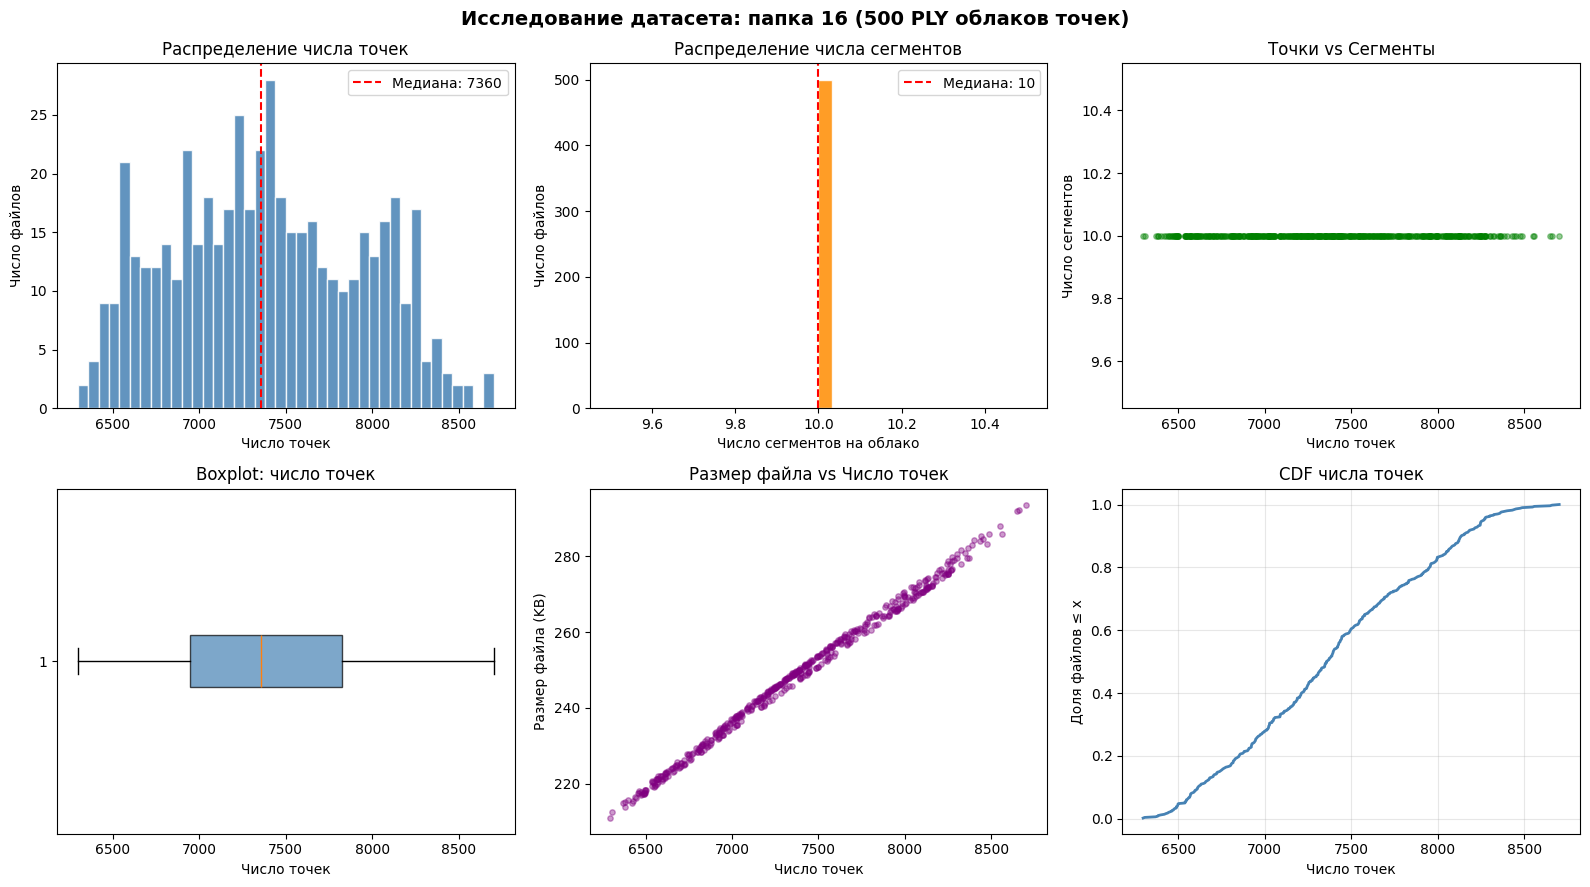

График сохранён → plots/dataset_statistics.png


In [12]:
stats = []
label_fields_found = {}
errors = []

for fname in tqdm(ply_files, desc="Scanning"):
    fpath = os.path.join(DATA_DIR, fname)
    pts, lf, meta = load_ply_with_labels(fpath)

    if pts is None:
        errors.append((fname, meta))
        continue

    n_points   = len(pts)
    labels     = pts[:, 3].astype(int)
    n_segments = len(np.unique(labels))
    fsize_kb   = os.path.getsize(fpath) / 1024

    stats.append({
        'file'        : fname,
        'n_points'    : n_points,
        'n_segments'  : n_segments,
        'label_field' : lf,
        'file_kb'     : round(fsize_kb, 1),
        'min_label'   : int(labels.min()),
        'max_label'   : int(labels.max()),
    })
    label_fields_found[lf] = label_fields_found.get(lf, 0) + 1

df_stats = pd.DataFrame(stats)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Исследование датасета: папка 16 (500 PLY облаков точек)',
             fontsize=14, fontweight='bold')

# Гистограмма числа точек
ax = axes[0, 0]
ax.hist(df_stats['n_points'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Распределение числа точек')
ax.set_xlabel('Число точек')
ax.set_ylabel('Число файлов')
ax.axvline(df_stats['n_points'].median(), color='red', ls='--', label=f"Медиана: {df_stats['n_points'].median():.0f}")
ax.legend()

# Гистограмма числа сегментов
ax = axes[0, 1]
ax.hist(df_stats['n_segments'], bins=30, color='darkorange', edgecolor='white', alpha=0.85)
ax.set_title('Распределение числа сегментов')
ax.set_xlabel('Число сегментов на облако')
ax.set_ylabel('Число файлов')
ax.axvline(df_stats['n_segments'].median(), color='red', ls='--',
           label=f"Медиана: {df_stats['n_segments'].median():.0f}")
ax.legend()

# Scatter: точки vs сегменты
ax = axes[0, 2]
ax.scatter(df_stats['n_points'], df_stats['n_segments'],
           alpha=0.4, s=15, color='green')
ax.set_title('Точки vs Сегменты')
ax.set_xlabel('Число точек')
ax.set_ylabel('Число сегментов')

# Boxplot числа точек
ax = axes[1, 0]
bp = ax.boxplot(df_stats['n_points'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_title('Boxplot: число точек')
ax.set_xlabel('Число точек')

# Размер файла vs число точек
ax = axes[1, 1]
ax.scatter(df_stats['n_points'], df_stats['file_kb'],
           alpha=0.4, s=15, color='purple')
ax.set_title('Размер файла vs Число точек')
ax.set_xlabel('Число точек')
ax.set_ylabel('Размер файла (KB)')

# Cumulative distribution
ax = axes[1, 2]
sorted_pts = np.sort(df_stats['n_points'])
cdf = np.arange(1, len(sorted_pts)+1) / len(sorted_pts)
ax.plot(sorted_pts, cdf, color='steelblue', linewidth=2)
ax.set_title('CDF числа точек')
ax.set_xlabel('Число точек')
ax.set_ylabel('Доля файлов ≤ x')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(DIRS['plots'], 'dataset_statistics.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"График сохранён → plots/dataset_statistics.png")


 Файл: valve_0001_lidar_classes.ply
   Точек: 6,757 | Сегментов: 10 | label-поле: 'scalar_Label'
   Размеры сегментов:
      label=   9 →  2,963 точек
      label=   5 →    928 точек
      label=   8 →    649 точек
      label=   6 →    621 точек
      label=   3 →    558 точек
      label=   7 →    410 точек
      label=   0 →    361 точек
      label=   1 →    143 точек
      label=   2 →     76 точек
      label=   4 →     48 точек


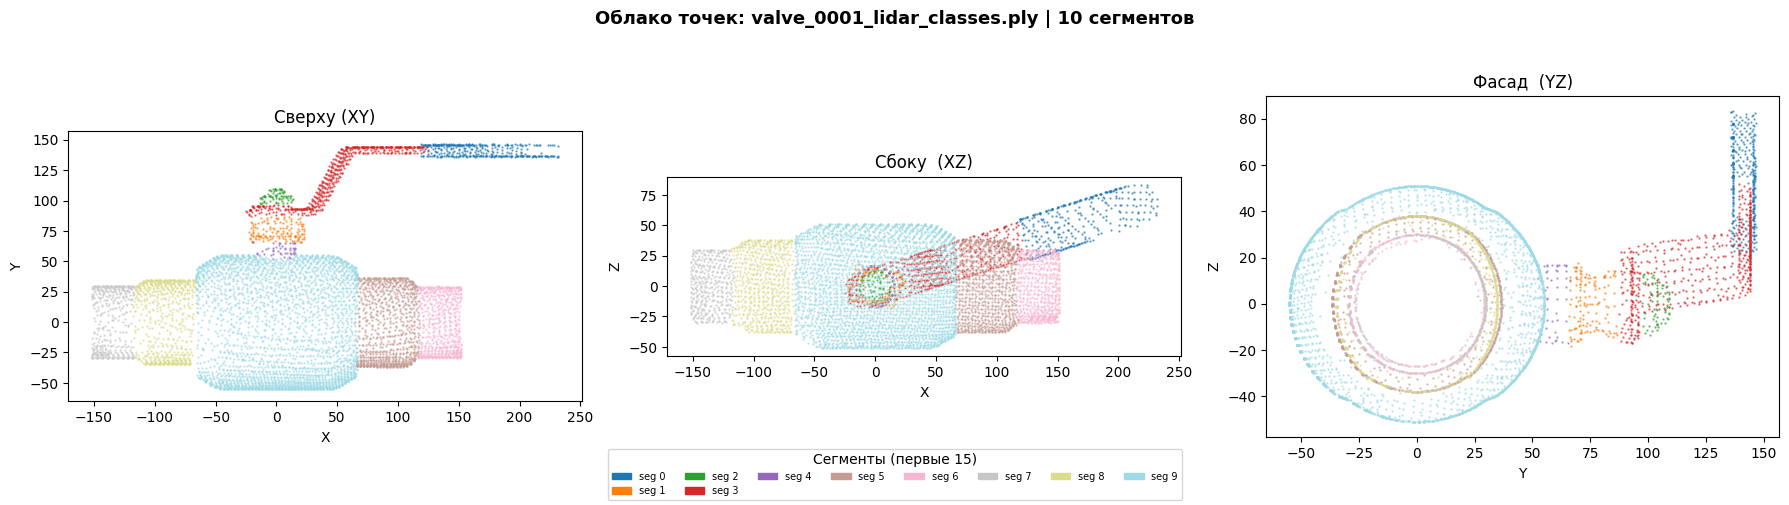

In [13]:
def visualize_cloud_segments_2d(points, title="Облако точек", save_path=None):

    labels  = points[:, 3].astype(int)
    unique_labels = np.unique(labels)
    cmap    = plt.cm.get_cmap('tab20', len(unique_labels))
    color_map = {l: cmap(i) for i, l in enumerate(unique_labels)}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    views = [
        (0, 1, 'Сверху (XY)', 'X', 'Y'),
        (0, 2, 'Сбоку  (XZ)', 'X', 'Z'),
        (1, 2, 'Фасад  (YZ)', 'Y', 'Z'),
    ]
    for ax, (xi, yi, vtitle, xl, yl) in zip(axes, views):
        for lbl in unique_labels:
            mask = labels == lbl
            ax.scatter(points[mask, xi], points[mask, yi],
                       s=0.5, color=color_map[lbl], alpha=0.6)
        ax.set_title(vtitle)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_aspect('equal')

    patches = [mpatches.Patch(color=color_map[l], label=f'seg {l}')
               for l in unique_labels[:15]]
    fig.legend(handles=patches, loc='lower center', ncol=8,
               fontsize=7, title='Сегменты (первые 15)')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


sample_indices = [0]   # первые

for idx in sample_indices:
    fname  = ply_files[idx]
    fpath  = os.path.join(DATA_DIR, fname)
    pts, lf, _ = load_ply_with_labels(fpath)

    if pts is None:
        continue

    labels    = pts[:, 3].astype(int)
    seg_sizes = {l: np.sum(labels == l) for l in np.unique(labels)}

    print(f"\n Файл: {fname}")
    print(f"   Точек: {len(pts):,} | Сегментов: {len(seg_sizes)} | label-поле: '{lf}'")
    print(f"   Размеры сегментов:")
    for l, sz in sorted(seg_sizes.items(), key=lambda x: -x[1])[:10]:
        print(f"      label={l:4d} → {sz:6,} точек")

    save_path = os.path.join(DIRS['plots'], f'sample_cloud_{idx:03d}.png')
    visualize_cloud_segments_2d(
        pts,
        title=f"Облако точек: {fname} | {len(seg_sizes)} сегментов",
        save_path=save_path
    )

In [14]:

obj_files = sorted([
    f for f in os.listdir(OBJ_DIR) if f.lower().endswith('.obj')
])

print(f" OBJ-эталоны найдено: {len(obj_files)}")
for f in obj_files:
    print(f"   {f}")

print("\n Детальный осмотр OBJ-файлов:\n")
obj_stats = []

for fname in obj_files:
    fpath = os.path.join(OBJ_DIR, fname)
    try:
        mesh = trimesh.load(fpath, process=False)

        if isinstance(mesh, trimesh.Scene):
            all_verts = sum(len(g.vertices) for g in mesh.geometry.values())
            all_faces = sum(len(g.faces)    for g in mesh.geometry.values())
            n_meshes  = len(mesh.geometry)
            bbox      = mesh.bounds if hasattr(mesh, 'bounds') else None
        else:
            all_verts = len(mesh.vertices)
            all_faces = len(mesh.faces)
            n_meshes  = 1
            bbox      = mesh.bounds

        bbox_size = (bbox[1] - bbox[0]) if bbox is not None else np.array([0,0,0])

        print(f"   {fname}")
        print(f"     Вершин : {all_verts:,}")
        print(f"     Граней  : {all_faces:,}")
        print(f"     Мешей   : {n_meshes}")
        if bbox is not None:
            print(f"     BBox    : {bbox_size.round(3)}")
        print()

        obj_stats.append({
            'file'    : fname,
            'vertices': all_verts,
            'faces'   : all_faces,
            'meshes'  : n_meshes,
        })

    except Exception as e:
        print(f"    {fname} — ошибка: {e}")

df_obj = pd.DataFrame(obj_stats)
df_obj.to_csv(os.path.join(DIRS['metrics'], 'obj_reference_stats.csv'), index=False)
print("Статистика OBJ сохранена → metrics/obj_reference_stats.csv")

 OBJ-эталоны найдено: 11
   16.01.obj
   16.02.obj
   16.03.obj
   16.04.obj
   16.05.obj
   16.06.obj
   16.07.obj
   16.08.obj
   16.09.obj
   16.10.obj
   16.obj

 Детальный осмотр OBJ-файлов:

   16.01.obj
     Вершин : 46,303
     Граней  : 25,454
     Мешей   : 1
     BBox    : [119.995  11.     34.   ]

   16.02.obj
     Вершин : 10,122
     Граней  : 6,448
     Мешей   : 1
     BBox    : [48.789 22.181 42.332]

   16.03.obj
     Вершин : 4,784
     Граней  : 2,744
     Мешей   : 1
     BBox    : [27.713 13.8   24.   ]

   16.04.obj
     Вершин : 5,243
     Граней  : 3,980
     Мешей   : 1
     BBox    : [147.198  55.997  30.   ]

   16.05.obj
     Вершин : 3,930
     Граней  : 2,904
     Мешей   : 1
     BBox    : [45.563 17.63  38.449]

   16.06.obj
     Вершин : 36,316
     Граней  : 18,656
     Мешей   : 1
     BBox    : [52.194 75.994 75.994]

   16.07.obj
     Вершин : 4,042
     Граней  : 2,522
     Мешей   : 1
     BBox    : [33.107 60.036 60.036]

   16.08.obj
     Верш

In [15]:
def preprocess_cloud(points, voxel_size=None, remove_noise=True,
                     min_points_ratio=0.001):
    """
    Предобработка облака точек:
    - удаление статистических выбросов
    - опциональный voxel downsampling
    Возвращает обработанные points (N,4) и словарь с инфо.
    """
    info = {'original_n': len(points), 'steps': []}
    pts_xyz = points[:, :3]
    labels  = points[:, 3]

    if remove_noise:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts_xyz)

        pcd_clean, ind = pcd.remove_statistical_outlier(
            nb_neighbors=20, std_ratio=2.0
        )
        pts_xyz = np.asarray(pcd_clean.points)
        labels  = labels[ind]
        info['after_denoise_n'] = len(pts_xyz)
        info['steps'].append(f"denoise: {info['original_n']} → {len(pts_xyz)}")

    if voxel_size is not None and voxel_size > 0:
        # voxel downsampling
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts_xyz)
        _, _, voxel_map = pcd.voxel_down_sample_and_trace(
            voxel_size,
            pcd.get_min_bound(),
            pcd.get_max_bound()
        )
        # для каждого вокселя берём первую точку
        indices = [int(v[0]) for v in voxel_map]
        pts_xyz = pts_xyz[indices]
        labels  = labels[indices]
        info['after_voxel_n'] = len(pts_xyz)
        info['steps'].append(f"voxel({voxel_size}): → {len(pts_xyz)}")

    result = np.column_stack([pts_xyz, labels])
    info['final_n'] = len(result)
    return result, info


def adaptive_voxel_size(n_points, target=5000, min_size=0.005, max_size=0.1):

    if n_points <= target:
        return None
    ratio = target / n_points
    vsize = min_size + (max_size - min_size) * (1 - ratio)
    return round(vsize, 4)



print("Тест предобработки:\n")
for idx in [0, 100, 400]:
    fname = ply_files[idx]
    pts, lf, _ = load_ply_with_labels(os.path.join(DATA_DIR, fname))
    if pts is None:
        continue

    vsize = adaptive_voxel_size(len(pts), target=8000)
    pts_clean, info = preprocess_cloud(pts, voxel_size=vsize)

    print(f"  {fname}")
    for step in info['steps']:
        print(f"    → {step}")
    print(f"    voxel_size: {vsize}")
    print(f"    Итого: {info['original_n']:,} → {info['final_n']:,} точек\n")

Тест предобработки:

  valve_0001_lidar_classes.ply
    → denoise: 6757 → 6416
    voxel_size: None
    Итого: 6,757 → 6,416 точек

  valve_0101_lidar_classes.ply
    → denoise: 7547 → 7274
    voxel_size: None
    Итого: 7,547 → 7,274 точек

  valve_0401_lidar_classes.ply
    → denoise: 6873 → 6555
    voxel_size: None
    Итого: 6,873 → 6,555 точек



#9

In [19]:
def extract_segments(points, min_points=30):
    """
    Формирует сегменты по полю scalar_Label.
    Каждый label = отдельная деталь клапана.
    """
    labels  = points[:, 3].astype(int)
    pts_xyz = points[:, :3]
    segments = {}

    for lbl in np.unique(labels):
        mask    = labels == lbl
        seg_pts = pts_xyz[mask]
        if len(seg_pts) >= min_points:
            segments[int(lbl)] = seg_pts

    return segments


print("✅ Сегментация по scalar_Label\n")

fname  = ply_files[0]
pts, lf, names = load_ply_with_labels(os.path.join(DATA_DIR, fname))

print(f"Файл: {fname}")
print(f"Поле label: '{lf}'")
print(f"Всего точек: {len(pts):,}")

segs = extract_segments(pts, min_points=30)
print(f"Сегментов: {len(segs)}\n")
print(f"  {'Label':>6} | {'Точек':>8} | {'% от total':>10}")
print(f"  {'-'*32}")
for lbl, spts in sorted(segs.items(), key=lambda x: -len(x[1])):
    pct = len(spts) / len(pts) * 100
    bar = '█' * int(pct / 2)
    print(f"  {lbl:>6} | {len(spts):>8,} | {pct:>9.1f}%  {bar}")


print(f"\n\n📊 Статистика сегментов по всем 500 файлам...\n")

seg_counts     = []
seg_sizes_all  = []
label_sets     = []   # какие label встречаются

for fname in tqdm(ply_files, desc="Анализ сегментов"):
    pts, _, _ = load_ply_with_labels(os.path.join(DATA_DIR, fname))
    if pts is None:
        continue

    segs = extract_segments(pts, min_points=30)
    seg_counts.append(len(segs))
    label_sets.append(set(segs.keys()))

    for lbl, spts in segs.items():
        seg_sizes_all.append({'label': lbl, 'n_points': len(spts), 'file': fname})

seg_counts    = np.array(seg_counts)
df_seg_sizes  = pd.DataFrame(seg_sizes_all)

print(f"Сегментов на облако:")
print(f"  min    = {seg_counts.min()}")
print(f"  median = {np.median(seg_counts):.1f}")
print(f"  mean   = {seg_counts.mean():.1f}")
print(f"  max    = {seg_counts.max()}")

print(f"\nРазмер сегмента (точек):")
print(f"  min    = {df_seg_sizes['n_points'].min()}")
print(f"  median = {df_seg_sizes['n_points'].median():.0f}")
print(f"  mean   = {df_seg_sizes['n_points'].mean():.0f}")
print(f"  max    = {df_seg_sizes['n_points'].max():,}")

print(f"\nСредний размер по label (усреднено по всем файлам):")
label_avg = df_seg_sizes.groupby('label')['n_points'].agg(['mean','median','count'])
label_avg = label_avg.sort_values('mean', ascending=False)
print(label_avg.round(0).to_string())

# насколько стабилен набор label от файла к файлу
all_labels_flat = set().union(*label_sets)
print(f"\nУникальных label в датасете: {sorted(all_labels_flat)}")

# сколько файлов имеют каждый label
for lbl in sorted(all_labels_flat):
    count = sum(1 for ls in label_sets if lbl in ls)
    print(f"  label={lbl}: присутствует в {count}/500 файлах")

MIN_SEGMENT_POINTS = int(df_seg_sizes['n_points'].quantile(0.05))
MIN_SEGMENT_POINTS = max(30, MIN_SEGMENT_POINTS)
print(f"\nMIN_SEGMENT_POINTS = {MIN_SEGMENT_POINTS}")

df_seg_sizes.to_csv(
    os.path.join(DIRS['metrics'], 'segment_size_by_label.csv'), index=False
)
print(f"→ metrics/segment_size_by_label.csv")

✅ Сегментация по scalar_Label

Файл: valve_0001_lidar_classes.ply
Поле label: 'scalar_Label'
Всего точек: 6,757
Сегментов: 10

   Label |    Точек | % от total
  --------------------------------
       9 |    2,963 |      43.9%  █████████████████████
       5 |      928 |      13.7%  ██████
       8 |      649 |       9.6%  ████
       6 |      621 |       9.2%  ████
       3 |      558 |       8.3%  ████
       7 |      410 |       6.1%  ███
       0 |      361 |       5.3%  ██
       1 |      143 |       2.1%  █
       2 |       76 |       1.1%  
       4 |       48 |       0.7%  


📊 Статистика сегментов по всем 500 файлам...



Анализ сегментов: 100%|██████████| 500/500 [00:31<00:00, 16.11it/s]

Сегментов на облако:
  min    = 10
  median = 10.0
  mean   = 10.0
  max    = 10

Размер сегмента (точек):
  min    = 37
  median = 574
  mean   = 738
  max    = 3,946

Средний размер по label (усреднено по всем файлам):
         mean  median  count
label                       
9      2947.0  2927.0    500
5      1027.0  1024.0    500
8       719.0   708.0    500
0       680.0   671.0    500
3       642.0   652.0    500
6       593.0   563.0    500
7       438.0   438.0    500
1       174.0   171.0    500
4        83.0    82.0    500
2        79.0    78.0    500

Уникальных label в датасете: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  label=0: присутствует в 500/500 файлах
  label=1: присутствует в 500/500 файлах
  label=2: присутствует в 500/500 файлах
  label=3: присутствует в 500/500 файлах
  label=4: присутствует в 500/500 файлах
  label=5: присутствует в 500/500 файлах
  label=6: присутствует в 500/500 файлах
  label=7: присутствует в 500/500 файлах
  label=8: присутствует в 500/500 файлах
 

Геоанализ и классификация

Полный геометрический анализ облака точек .
Применяется ко всему облаку клапана целиком.
Масштаб данных: координаты ~0-150 после центрирования, mean_nn ~2-3.

In [20]:
def analyze_segment_geometry(pts):

    result = {}
    n = len(pts)

    if n < 10:
        return {'error': 'too_few_points', 'n_points': n}

    result['n_points'] = n
    tree = KDTree(pts)

    # ── 6.1 Плотность точек
    k_nn     = min(6, n - 1)
    dists, _ = tree.query(pts, k=k_nn + 1)
    nn_dist  = dists[:, 1:]
    mean_nn  = float(nn_dist.mean())
    std_nn   = float(nn_dist.std())

    result['density_mean_nn'] = mean_nn
    result['density_std_nn']  = std_nn
    result['density_cv']      = float(std_nn / (mean_nn + 1e-9))

    # пороги под реальный масштаб (mean_nn ~2-3 единицы)
    if mean_nn < 1.5:
        result['density_level'] = 'high'
    elif mean_nn < 4.0:
        result['density_level'] = 'medium'
    else:
        result['density_level'] = 'low'

    # ── 6.2 Форма распределения (PCA)
    pts_c = pts - pts.mean(axis=0)
    pca   = PCA(n_components=3)
    pca.fit(pts_c)
    ev    = pca.explained_variance_ratio_

    result['pca_ev']         = ev.tolist()
    result['pca_ev1']        = float(ev[0])
    result['pca_ev2']        = float(ev[1])
    result['pca_ev3']        = float(ev[2])
    result['pca_linearity']  = float((ev[0] - ev[1]) / (ev[0] + 1e-9))
    result['pca_planarity']  = float((ev[1] - ev[2]) / (ev[0] + 1e-9))
    result['pca_sphericity'] = float(ev[2]  / (ev[0] + 1e-9))

    if ev[0] > 0.85:
        result['shape_type'] = 'linear'
    elif ev[0] + ev[1] > 0.95:
        result['shape_type'] = 'planar'
    elif result['pca_sphericity'] > 0.5:
        result['shape_type'] = 'spherical'
    else:
        result['shape_type'] = 'complex'

    # ── 6.3 Кривизна поверхности
    k_curv     = min(15, n - 1)
    _, idx_all = tree.query(pts, k=k_curv + 1)
    sample_idx = np.random.choice(n, min(500, n), replace=False)
    curvatures = []

    for i in sample_idx:
        neighbors = pts[idx_all[i, 1:]]
        if len(neighbors) < 3:
            continue
        lp  = PCA(n_components=3)
        lp.fit(neighbors - neighbors.mean(axis=0))
        lev = lp.explained_variance_ratio_
        curvatures.append(float(lev[2]))

    if curvatures:
        ca = np.array(curvatures)
        result['curvature_mean'] = float(ca.mean())
        result['curvature_std']  = float(ca.std())
        result['curvature_max']  = float(ca.max())
        result['curvature_p90']  = float(np.percentile(ca, 90))

        # пороги откалиброваны под реальные данные (curv median ~0.03)
        if ca.mean() < 0.02:
            result['surface_type'] = 'smooth'
        elif ca.mean() < 0.06:
            result['surface_type'] = 'slightly_curved'
        elif ca.mean() < 0.15:
            result['surface_type'] = 'highly_curved'
        else:
            result['surface_type'] = 'complex'
    else:
        result['curvature_mean'] = 0.0
        result['surface_type']   = 'unknown'

    # ── 6.4 Согласованность нормалей
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamKNN(knn=min(20, n - 1))
    )
    try:
        pcd.orient_normals_consistent_tangent_plane(k=min(15, n - 1))
    except:
        pass

    normals = np.asarray(pcd.normals)
    if len(normals) > 1:
        _, nidx = tree.query(pts, k=min(6, n))
        cons = []
        for i in range(min(len(normals), 800)):
            neigh_n = normals[nidx[i, 1:]]
            cos_sim = np.abs(neigh_n @ normals[i])
            cons.append(float(cos_sim.mean()))
        nc = np.array(cons)
        result['normal_consistency_mean'] = float(nc.mean())
        result['normal_consistency_std']  = float(nc.std())
        result['normal_quality'] = (
            'high'   if nc.mean() > 0.85 else
            'medium' if nc.mean() > 0.65 else
            'low'
        )
    else:
        result['normal_consistency_mean'] = 0.0
        result['normal_quality']          = 'unknown'

    # ── 6.5 Топологическая связность
    # eps = mean_nn * 3 гарантирует что связный объект даст 1 компоненту
    eps_conn = mean_nn * 3.0
    db       = DBSCAN(eps=eps_conn, min_samples=3).fit(pts)
    db_lbl   = db.labels_
    n_comp   = len(set(db_lbl)) - (1 if -1 in db_lbl else 0)
    n_noise  = int(np.sum(db_lbl == -1))

    result['n_components'] = int(n_comp)
    result['n_noise_pts']  = n_noise
    result['noise_ratio']  = float(n_noise / n)
    result['topology']     = (
        'connected'      if n_comp == 1 and n_noise / n < 0.05 else
        'few_components' if n_comp <= 3 else
        'fragmented'
    )

    return result




    Классификация геометрии детали клапана + выбор метода реконструкции.

    Классы геометрии:
    - planar    → фланцы, плоские крышки
    - tubular   → патрубки, шток
    - spherical → шарообразный корпус
    - complex   → корпус клапана, сложные детали

    Методы:
    - poisson      → гладкие поверхности, хорошие нормали
    - ball_pivoting → равномерная плотность, умеренная кривизна
    - alpha_shape  → сложная геометрия, шум, мелкие детали


In [22]:
def classify_segment(geo):

    if 'error' in geo:
        return 'unknown', 'alpha_shape'

    shape    = geo.get('shape_type', 'complex')
    normal_q = geo.get('normal_quality', 'low')
    topology = geo.get('topology', 'fragmented')
    curv     = geo.get('curvature_mean', 0.5)
    n_pts    = geo.get('n_points', 0)
    ev1      = geo.get('pca_ev1', 0)
    ev2      = geo.get('pca_ev2', 0)
    spher    = geo.get('pca_sphericity', 0)
    nc_mean  = geo.get('normal_consistency_mean', 0)

    # ── Классификация
    if shape == 'planar' or (ev1 + ev2 > 0.97 and curv < 0.04):
        geo_class = 'planar'

    elif shape == 'linear' or ev1 > 0.82:
        geo_class = 'tubular'

    elif shape == 'spherical' or (spher > 0.45 and 0.04 < curv < 0.12):
        geo_class = 'spherical'

    else:
        geo_class = 'complex'

    # ── Выбор метода реконструкции
    if geo_class == 'planar':
        method = 'poisson' if normal_q in ('high', 'medium') else 'alpha_shape'

    elif geo_class == 'tubular':
        method = (
            'ball_pivoting'
            if topology in ('connected', 'few_components')
            else 'alpha_shape'
        )

    elif geo_class == 'spherical':
        method = (
            'ball_pivoting'
            if normal_q in ('high', 'medium') and topology == 'connected'
            else 'poisson'
        )

    else:  # complex — основной тип для клапанов
        if normal_q == 'high' and topology == 'connected':
            method = 'poisson'
        elif topology in ('connected', 'few_components') and nc_mean > 0.60:
            method = 'ball_pivoting'
        else:
            method = 'alpha_shape'

    return geo_class, method



In [23]:

print("Геоанализ сегментов первого файла:\n")

pts0, _, _ = load_ply_with_labels(os.path.join(DATA_DIR, ply_files[0]))
pts0_norm  = pts0.copy()
pts0_norm[:, :3] = pts0[:, :3] - pts0[:, :3].mean(axis=0)  # центрируем

segs0 = extract_segments(pts0_norm, min_points=30)

print(f"  {'Label':>5} | {'N pts':>6} | {'Форма':>10} | "
      f"{'Поверхн.':>16} | {'Нормали':>8} | {'Топол.':>14} | Кривизна")
print(f"  {'-'*90}")

geo_sample = []
for lbl, spts in sorted(segs0.items(), key=lambda x: -len(x[1])):
    geo = analyze_segment_geometry(spts)
    gc, method = classify_segment(geo)
    geo_sample.append({**geo, 'label': lbl, 'geo_class': gc, 'method': method})
    print(f"  {lbl:>5} | {len(spts):>6,} | "
          f"{geo.get('shape_type','?'):>10} | "
          f"{geo.get('surface_type','?'):>16} | "
          f"{geo.get('normal_quality','?'):>8} | "
          f"{geo.get('topology','?'):>14} | "
          f"{geo.get('curvature_mean',0):.4f}  → {gc} / {method}")

Геоанализ сегментов первого файла:

  Label |  N pts |      Форма |         Поверхн. |  Нормали |         Топол. | Кривизна
  ------------------------------------------------------------------------------------------
      9 |  2,963 |  spherical |           smooth |     high |      connected | 0.0057  → spherical / ball_pivoting
      5 |    928 |    complex |           smooth |     high |      connected | 0.0056  → complex / poisson
      8 |    649 |    complex |           smooth |     high |      connected | 0.0056  → complex / poisson
      6 |    621 |    complex |  slightly_curved |     high |      connected | 0.0328  → complex / poisson
      3 |    558 |     linear |    highly_curved |     high |      connected | 0.1028  → tubular / ball_pivoting
      7 |    410 |    complex |  slightly_curved |     high |      connected | 0.0202  → complex / poisson
      0 |    361 |     linear |    highly_curved |     high |      connected | 0.1001  → tubular / ball_pivoting
      1 |    1

In [24]:

print(f"\n\nСтатистика классификации по 50 файлам...\n")

class_dist  = {}
method_dist = {}
all_geos_50 = []

for fname in tqdm(ply_files[:50], desc="Классификация"):
    pts, _, _ = load_ply_with_labels(os.path.join(DATA_DIR, fname))
    if pts is None:
        continue
    pts_c = pts.copy()
    pts_c[:, :3] = pts[:, :3] - pts[:, :3].mean(axis=0)
    segs = extract_segments(pts_c, min_points=MIN_SEGMENT_POINTS)

    for lbl, spts in segs.items():
        geo        = analyze_segment_geometry(spts)
        gc, method = classify_segment(geo)
        class_dist[gc]      = class_dist.get(gc, 0) + 1
        method_dist[method] = method_dist.get(method, 0) + 1
        all_geos_50.append({
            **geo,
            'label'    : lbl,
            'geo_class': gc,
            'method'   : method,
            'file'     : fname,
        })

total_segs = sum(class_dist.values())

print(f"  Классы геометрии (всего сегментов: {total_segs}):")
for cls, cnt in sorted(class_dist.items(), key=lambda x: -x[1]):
    bar = '█' * int(cnt / total_segs * 40)
    pct = cnt / total_segs * 100
    print(f"    {cls:12s}: {cnt:4d} ({pct:5.1f}%)  {bar}")

print(f"\n  Методы реконструкции:")
for m, cnt in sorted(method_dist.items(), key=lambda x: -x[1]):
    bar = '█' * int(cnt / total_segs * 40)
    pct = cnt / total_segs * 100
    print(f"    {m:15s}: {cnt:4d} ({pct:5.1f}%)  {bar}")

# распределение методов по label (какой метод для какой детали)
print(f"\n  Метод по label (усредн. по 50 файлам):")
df_50 = pd.DataFrame(all_geos_50)
if len(df_50) > 0:
    cross = df_50.groupby(['label', 'method']).size().unstack(fill_value=0)
    print(cross.to_string())

df_50.to_csv(
    os.path.join(DIRS['metrics'], 'geo_analysis_50_sample.csv'), index=False
)
print(f"\n → metrics/geo_analysis_50_sample.csv")



Статистика классификации по 50 файлам...



Классификация: 100%|██████████| 50/50 [02:07<00:00,  2.55s/it]

  Классы геометрии (всего сегментов: 477):
    complex     :  338 ( 70.9%)  ████████████████████████████
    tubular     :   88 ( 18.4%)  ███████
    spherical   :   36 (  7.5%)  ███
    planar      :   15 (  3.1%)  █

  Методы реконструкции:
    poisson        :  350 ( 73.4%)  █████████████████████████████
    ball_pivoting  :  127 ( 26.6%)  ██████████

  Метод по label (усредн. по 50 файлам):
method  ball_pivoting  poisson
label                         
0                  38       12
1                   0       50
2                   0       43
3                  50        0
4                   0       34
5                   0       50
6                   0       50
7                   1       49
8                   1       49
9                  37       13

 → metrics/geo_analysis_50_sample.csv


три метода реконструкции


- Poisson Surface Reconstruction с улучшенной обрезкой артефактов.
    Для мелких сегментов depth снижается автоматически.

- Ball Pivoting Algorithm.
    Хорош для равномерно распределённых точек умеренной кривизны.
    Радиусы выбираются автоматически по среднему расстоянию между соседями.

-   Alpha Shapes.
    Надёжный fallback для сложной геометрии, шума и мелких сегментов.
    Alpha выбирается автоматически по среднему расстоянию между соседями.

In [29]:
def reconstruct_poisson(pts, depth=8):

    try:
        if len(pts) < 50:
            return None, "too_few_points"

        # адаптивная глубина под размер сегмента
        if len(pts) < 100:
            actual_depth = 5
        elif len(pts) < 300:
            actual_depth = 6
        elif len(pts) < 1000:
            actual_depth = 7
        else:
            actual_depth = depth

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamKNN(
                knn=min(20, len(pts) - 1)
            )
        )
        pcd.orient_normals_consistent_tangent_plane(k=min(15, len(pts) - 1))

        mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
            pcd, depth=actual_depth, width=0, scale=1.1, linear_fit=False
        )

        # обрезаем артефакты — убираем 20% вершин с низкой плотностью
        # (было 10%, увеличиваем чтобы снизить RMSE у planar)
        densities = np.asarray(densities)
        thresh    = np.percentile(densities, 20)
        mesh.remove_vertices_by_mask(densities < thresh)
        mesh.remove_degenerate_triangles()
        mesh.remove_duplicated_triangles()
        mesh.remove_unreferenced_vertices()

        if len(mesh.triangles) < 4:
            return None, "degenerate_mesh"

        return mesh, "ok"

    except Exception as e:
        return None, str(e)


def reconstruct_ball_pivoting(pts):
    try:
        if len(pts) < 50:
            return None, "too_few_points"

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamKNN(knn=min(20, len(pts)-1))
        )
        pcd.orient_normals_consistent_tangent_plane(k=min(15, len(pts)-1))

        # автоматический выбор радиусов через среднее расстояние соседей
        tree      = KDTree(pts)
        dists, _  = tree.query(pts, k=2)
        mean_dist = float(dists[:, 1].mean())

        # три радиуса: малый / средний / крупный
        radii     = [mean_dist * 0.5,
                     mean_dist * 1.0,
                     mean_dist * 2.0,
                     mean_dist * 4.0]
        radii_o3d = o3d.utility.DoubleVector(radii)

        mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
            pcd, radii_o3d
        )
        mesh.remove_degenerate_triangles()
        mesh.remove_duplicated_triangles()
        mesh.remove_unreferenced_vertices()

        if len(mesh.triangles) < 4:
            return None, "degenerate_mesh"

        return mesh, "ok"

    except Exception as e:
        return None, str(e)


def reconstruct_alpha_shape(pts):
    try:
        if len(pts) < 20:
            return None, "too_few_points"

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)

        # автоматический alpha
        tree     = KDTree(pts)
        dists, _ = tree.query(pts, k=2)
        alpha    = float(dists[:, 1].mean()) * 4.0

        mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
            pcd, alpha
        )
        mesh.remove_degenerate_triangles()
        mesh.remove_duplicated_triangles()
        mesh.remove_unreferenced_vertices()

        # если мало граней — пробуем больший alpha
        if len(mesh.triangles) < 4:
            mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
                pcd, alpha * 2.0
            )
            mesh.remove_degenerate_triangles()
            mesh.remove_duplicated_triangles()

        if len(mesh.triangles) < 4:
            return None, "degenerate_mesh"

        return mesh, "ok"

    except Exception as e:
        return None, str(e)


def reconstruct_segment(pts, method):
    """Диспетчер: вызывает нужный метод реконструкции."""
    if method == 'poisson':
        return reconstruct_poisson(pts)
    elif method == 'ball_pivoting':
        return reconstruct_ball_pivoting(pts)
    elif method == 'alpha_shape':
        return reconstruct_alpha_shape(pts)
    else:
        return None, f"unknown_method:{method}"


print("Тест методов реконструкции на сегментах первого файла:\n")

pts0, _, _  = load_ply_with_labels(os.path.join(DATA_DIR, ply_files[0]))
pts0_c      = pts0.copy()
pts0_c[:, :3] = pts0[:, :3] - pts0[:, :3].mean(axis=0)
segs0       = extract_segments(pts0_c, min_points=MIN_SEGMENT_POINTS)

print(f"  {'Label':>5} | {'N pts':>6} | {'Метод':>14} | "
      f"{'Статус':>20} | {'Граней':>7} | {'Вершин':>7}")
print(f"  {'-'*75}")

for lbl, spts in sorted(segs0.items(), key=lambda x: -len(x[1])):
    geo        = analyze_segment_geometry(spts)
    gc, method = classify_segment(geo)
    mesh, status = reconstruct_segment(spts, method)

    n_faces = len(mesh.triangles) if mesh is not None else 0
    n_verts = len(mesh.vertices)  if mesh is not None else 0

    print(f"  {lbl:>5} | {len(spts):>6,} | {method:>14} | "
          f"{status:>20} | {n_faces:>7,} | {n_verts:>7,}")

print(f"\n гтово")

Тест методов реконструкции на сегментах первого файла:

  Label |  N pts |          Метод |               Статус |  Граней |  Вершин
  ---------------------------------------------------------------------------
      9 |  2,963 |  ball_pivoting |                   ok |   5,742 |   2,946
      5 |    928 |        poisson |                   ok |   6,161 |   3,189
      8 |    649 |        poisson |                   ok |   6,035 |   3,132
      6 |    621 |        poisson |                   ok |   6,370 |   3,321
      3 |    558 |  ball_pivoting |                   ok |     812 |     450
      7 |    410 |        poisson |                   ok |   6,179 |   3,240
      0 |    361 |  ball_pivoting |                   ok |     515 |     299
      1 |    143 |        poisson |                   ok |   5,426 |   2,833
      2 |     76 |        poisson |                   ok |   3,735 |   1,957

 гтово


метрики качества

 Оценка качества реконструированной сетки.

    Метрики:
    - cloud_to_mesh_rmse  : RMSE расстояний от облака точек до сетки
    - mesh_to_cloud_rmse  : RMSE в обратную сторону
    - hausdorff_approx    : приближённое расстояние Хаусдорфа
    - n_faces / n_verts   : размер сетки
    - n_mesh_components   : число связных компонент сетки
    - largest_comp_ratio  : доля крупнейшей компоненты
    - surface_area        : площадь поверхности
    

In [30]:
def compute_reconstruction_quality(mesh, original_pts):

    metrics = {}

    if mesh is None or len(mesh.triangles) == 0:
        return {'error': 'no_mesh'}

    n_verts = len(mesh.vertices)
    n_faces = len(mesh.triangles)
    metrics['n_vertices'] = n_verts
    metrics['n_faces']    = n_faces

    mesh_pts = np.asarray(mesh.vertices)

    if len(mesh_pts) > 0 and len(original_pts) > 0:
        # расстояние облако → сетка
        tree_mesh    = KDTree(mesh_pts)
        d_c2m, _     = tree_mesh.query(original_pts)
        metrics['cloud_to_mesh_mean']   = float(d_c2m.mean())
        metrics['cloud_to_mesh_max']    = float(d_c2m.max())
        metrics['cloud_to_mesh_rmse']   = float(np.sqrt((d_c2m**2).mean()))
        metrics['cloud_to_mesh_median'] = float(np.median(d_c2m))

        # расстояние сетка → облако (семплируем до 3000 вершин)
        sample_n     = min(len(mesh_pts), 3000)
        sample_idx   = np.random.choice(len(mesh_pts), sample_n, replace=False)
        tree_cloud   = KDTree(original_pts)
        d_m2c, _     = tree_cloud.query(mesh_pts[sample_idx])
        metrics['mesh_to_cloud_mean']   = float(d_m2c.mean())
        metrics['mesh_to_cloud_rmse']   = float(np.sqrt((d_m2c**2).mean()))

        # приближённый Хаусдорф
        metrics['hausdorff_approx'] = float(
            max(d_c2m.max(), d_m2c.max())
        )

    # площадь поверхности
    try:
        metrics['surface_area'] = float(mesh.get_surface_area())
    except:
        metrics['surface_area'] = 0.0

    # связность сетки
    try:
        tri_clusters, cluster_n_tri, _ = mesh.cluster_connected_triangles()
        n_comp = len(cluster_n_tri)
        metrics['n_mesh_components']   = int(n_comp)
        metrics['largest_comp_ratio']  = float(
            max(cluster_n_tri) / n_faces if n_faces > 0 else 0
        )
    except:
        metrics['n_mesh_components']  = -1
        metrics['largest_comp_ratio'] = 0.0

    return metrics


print("Тест метрик качества:\n")

print(f"  {'Label':>5} | {'N pts':>6} | {'Метод':>14} | "
      f"{'RMSE c→m':>10} | {'RMSE m→c':>10} | "
      f"{'Hausdorff':>10} | {'Граней':>7} | {'Компон.':>7}")
print(f"  {'-'*95}")

for lbl, spts in sorted(segs0.items(), key=lambda x: -len(x[1])):
    geo          = analyze_segment_geometry(spts)
    gc, method   = classify_segment(geo)
    mesh, status = reconstruct_segment(spts, method)
    q            = compute_reconstruction_quality(mesh, spts)

    if 'error' in q:
        print(f"  {lbl:>5} | {len(spts):>6,} | {method:>14} | "
              f"  {'ОШИБКА: ' + status:>50}")
        continue

    print(f"  {lbl:>5} | {len(spts):>6,} | {method:>14} | "
          f"{q.get('cloud_to_mesh_rmse',0):>10.4f} | "
          f"{q.get('mesh_to_cloud_rmse',0):>10.4f} | "
          f"{q.get('hausdorff_approx',0):>10.4f} | "
          f"{q.get('n_faces',0):>7,} | "
          f"{q.get('n_mesh_components',-1):>7}")


Тест метрик качества:

  Label |  N pts |          Метод |   RMSE c→m |   RMSE m→c |  Hausdorff |  Граней | Компон.
  -----------------------------------------------------------------------------------------------
      9 |  2,963 |  ball_pivoting |     0.2941 |     0.0000 |     4.1994 |   5,742 |       1
      5 |    928 |        poisson |     1.0788 |     3.4430 |    12.2533 |   6,164 |       1
      8 |    649 |        poisson |     1.0623 |     4.5857 |    19.0329 |   6,035 |       1
      6 |    621 |        poisson |     1.0702 |     3.9471 |    11.4070 |   6,370 |       2
      3 |    558 |  ball_pivoting |     2.1257 |     0.0000 |     5.7614 |     812 |       1
      7 |    410 |        poisson |     0.9196 |     4.3594 |    14.9050 |   6,179 |       5
      0 |    361 |  ball_pivoting |     3.0614 |     0.0000 |    10.8890 |     515 |       2
      1 |    143 |        poisson |     1.0111 |     4.3987 |    12.0347 |   5,428 |      10
      2 |     76 |        poisson |     0.

  Полный pipeline для одного PLY-файла клапана:
    загрузка → денойз → центрирование → сегментация по label
    → геоанализ → классификация → реконструкция → сборка → метрики

In [31]:
def process_single_cloud(fname, data_dir, min_seg_pts, save_dir_models):

    fpath = os.path.join(data_dir, fname)
    stem  = os.path.splitext(fname)[0]

    result = {
        'file'        : fname,
        'status'      : 'ok',
        'n_points_raw': 0,
        'n_segments'  : 0,
        'n_success'   : 0,
        'n_failed'    : 0,
        'total_faces' : 0,
        'total_verts' : 0,
        'segments'    : [],
    }

    # 1. Загрузка
    pts, lf, err = load_ply_with_labels(fpath)
    if pts is None:
        result['status'] = f'load_error:{err}'
        return result
    result['n_points_raw'] = len(pts)

    # 2. Денойз
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts[:, :3])
    pcd_clean, ind = pcd.remove_statistical_outlier(
        nb_neighbors=20, std_ratio=2.0
    )
    pts_clean      = pts[ind].copy()
    pts_clean[:, :3] = np.asarray(pcd_clean.points)

    # 3. Центрирование координат
    centroid         = pts_clean[:, :3].mean(axis=0)
    pts_clean[:, :3] -= centroid
    result['centroid'] = centroid.tolist()

    # 4. Сегментация по scalar_Label
    segs = extract_segments(pts_clean, min_points=min_seg_pts)
    result['n_segments'] = len(segs)

    if len(segs) == 0:
        result['status'] = 'no_segments'
        return result

    all_meshes   = []
    geo_classes  = []
    methods_used = []

    for lbl, seg_pts in segs.items():

        # 5. Геометрический анализ
        geo = analyze_segment_geometry(seg_pts)

        # 6. Классификация + выбор метода
        geo_class, method = classify_segment(geo)
        geo_classes.append(geo_class)
        methods_used.append(method)

        # 7. Реконструкция
        mesh, status = reconstruct_segment(seg_pts, method)

        # 8. Метрики качества
        q = compute_reconstruction_quality(mesh, seg_pts)

        result['segments'].append({
            'label'     : int(lbl),
            'n_points'  : len(seg_pts),
            'geo_class' : geo_class,
            'method'    : method,
            'rec_status': status,
            **{k: v for k, v in q.items() if k != 'error'},
        })

        if mesh is not None and len(mesh.triangles) > 0:
            all_meshes.append(mesh)
            result['n_success'] += 1
        else:
            result['n_failed'] += 1

    result['geo_class_majority'] = (
        max(set(geo_classes), key=geo_classes.count)
        if geo_classes else 'unknown'
    )
    result['methods_used'] = list(set(methods_used))

    # 9. Сборка итоговой модели из всех сегментов
    if all_meshes:
        combined = all_meshes[0]
        for m in all_meshes[1:]:
            combined += m
        combined.remove_duplicated_triangles()
        combined.remove_degenerate_triangles()
        combined.remove_unreferenced_vertices()
        combined.compute_vertex_normals()

        out_path = os.path.join(save_dir_models, f'{stem}_reconstructed.ply')
        o3d.io.write_triangle_mesh(out_path, combined)
        result['output_model'] = out_path
        result['total_faces']  = len(combined.triangles)
        result['total_verts']  = len(combined.vertices)
    else:
        result['output_model'] = None

    return result






In [32]:
print(" Тест pipeline на 3 файлах:\n")

for idx in [0, 250, 499]:
    t0  = time.time()
    res = process_single_cloud(
        ply_files[idx], DATA_DIR, MIN_SEGMENT_POINTS, DIRS['models']
    )
    dt = time.time() - t0

    print(f"  {ply_files[idx]}")
    print(f"    Точек: {res['n_points_raw']:,} | Сегм: {res['n_segments']} | "
          f"OK: {res['n_success']} | Failed: {res['n_failed']} | "
          f"Граней: {res.get('total_faces',0):,} | Время: {dt:.1f}s")

    for s in res['segments']:
        rmse    = s.get('cloud_to_mesh_rmse', -1)
        rmse_s  = f"{rmse:.4f}" if isinstance(rmse, float) and rmse > 0 else "—"
        faces   = s.get('n_faces', 0)
        print(f"      label={s['label']:>2} | {s['geo_class']:10s} | "
              f"{s['method']:14s} | {s['rec_status']:25s} | "
              f"faces={faces:5,} | RMSE={rmse_s}")
    print()

est_total = dt * 500
print(f" Оценка: ~{est_total/60:.0f} мин на 500 файлов (по {dt:.1f}s/файл)")
print(f"\n{'='*50}")
print(f" полный pipeline на 500 файлах...")
print(f"{'='*50}\n")


 Тест pipeline на 3 файлах:

  valve_0001_lidar_classes.ply
    Точек: 6,757 | Сегм: 9 | OK: 9 | Failed: 0 | Граней: 32,077 | Время: 7.0s
      label= 0 | planar     | poisson        | ok                        | faces=2,192 | RMSE=1.9476
      label= 1 | complex    | poisson        | ok                        | faces=5,651 | RMSE=0.8691
      label= 2 | complex    | poisson        | ok                        | faces=3,735 | RMSE=0.4212
      label= 3 | tubular    | ball_pivoting  | ok                        | faces=  812 | RMSE=2.1257
      label= 5 | complex    | poisson        | ok                        | faces=6,161 | RMSE=1.0788
      label= 6 | complex    | poisson        | ok                        | faces=6,370 | RMSE=1.0702
      label= 7 | complex    | ball_pivoting  | ok                        | faces=  606 | RMSE=0.5801
      label= 8 | complex    | ball_pivoting  | ok                        | faces=1,057 | RMSE=0.2098
      label= 9 | spherical  | ball_pivoting  | ok     

In [33]:

CHECKPOINT_PATH = os.path.join(DIRS['logs'], 'checkpoint.json')

if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        all_results = json.load(f)
    done_files  = {r['file'] for r in all_results}
    failed_files = [(r['file'], r['status'])
                    for r in all_results if r['status'] != 'ok']
    print(f" Найден чекпоинт: уже обработано {len(all_results)} файлов")
    print(f"   Осталось: {500 - len(all_results)} файлов")
else:
    all_results  = []
    failed_files = []
    done_files   = set()
    print(f" Чекпоинт не найден — начинаем с начала")

# файлы которые ещё не обработаны
remaining_files = [f for f in ply_files if f not in done_files]
print(f" Запускаем pipeline на {len(remaining_files)} файлах...\n")

t_start = time.time()

for i, fname in enumerate(tqdm(remaining_files, desc="Pipeline")):
    try:
        res = process_single_cloud(
            fname, DATA_DIR, MIN_SEGMENT_POINTS, DIRS['models']
        )
        all_results.append(res)
        if res['status'] != 'ok':
            failed_files.append((fname, res['status']))

    except Exception as e:
        failed_files.append((fname, str(e)))
        all_results.append({
            'file'        : fname,
            'status'      : f'exception:{str(e)[:50]}',
            'n_success'   : 0,
            'n_failed'    : 0,
            'n_points_raw': 0,
            'n_segments'  : 0,
            'total_faces' : 0,
            'total_verts' : 0,
            'segments'    : [],
        })

    # чекпоинт каждые 50 файлов
    if (i + 1) % 50 == 0:
        with open(CHECKPOINT_PATH, 'w') as f:
            json.dump(all_results, f)

        elapsed  = time.time() - t_start
        eta      = elapsed / (i + 1) * (len(remaining_files) - i - 1)
        n_ok     = sum(1 for r in all_results if r['status'] == 'ok')
        avg_f    = np.mean([r.get('total_faces', 0)
                            for r in all_results
                            if r['status'] == 'ok']) if n_ok > 0 else 0
        print(f"\n  Чекпоинт сохранён [{len(all_results)}/500] | "
              f"{elapsed:.0f}s | ETA: {eta:.0f}s | "
              f"OK: {n_ok} | Failed: {len(failed_files)} | "
              f"avg faces: {avg_f:,.0f}")

# финальный чекпоинт
with open(CHECKPOINT_PATH, 'w') as f:
    json.dump(all_results, f)

total_time = time.time() - t_start
n_ok       = sum(1 for r in all_results if r['status'] == 'ok')
avg_faces  = np.mean([r.get('total_faces', 0)
                      for r in all_results
                      if r['status'] == 'ok']) if n_ok > 0 else 0

print(f"\n{'='*50}")
print(f"  PIPELINE ЗАВЕРШЁН")
print(f"  Время      : {total_time:.0f}s ({total_time/60:.1f} мин)")
print(f"  Успешно    : {n_ok}/500")
print(f"  С ошибками : {len(failed_files)}")
print(f"  Avg граней : {avg_faces:,.0f}")
print(f"{'='*50}")

if failed_files:
    with open(os.path.join(DIRS['logs'], 'failed_files.txt'), 'w') as f:
        for fn, err in failed_files:
            f.write(f"{fn}: {err}\n")
    print(f"\n Лог ошибок → logs/failed_files.txt")

 Чекпоинт не найден — начинаем с начала
 Запускаем pipeline на 500 файлах...



Pipeline:  10%|█         | 50/500 [06:12<54:43,  7.30s/it]


  Чекпоинт сохранён [50/500] | 372s | ETA: 3350s | OK: 50 | Failed: 0 | avg faces: 43,789


Pipeline:  20%|██        | 100/500 [12:17<45:39,  6.85s/it]


  Чекпоинт сохранён [100/500] | 737s | ETA: 2950s | OK: 100 | Failed: 0 | avg faces: 43,574


...


  Чекпоинт сохранён [400/500] | 2827s | ETA: 707s | OK: 400 | Failed: 0 | avg faces: 42,216


Pipeline:  90%|█████████ | 450/500 [53:01<05:34,  6.69s/it]


  Чекпоинт сохранён [450/500] | 3181s | ETA: 353s | OK: 450 | Failed: 0 | avg faces: 42,197


Pipeline: 100%|██████████| 500/500 [59:08<00:00,  7.10s/it]


  Чекпоинт сохранён [500/500] | 3549s | ETA: 0s | OK: 500 | Failed: 0 | avg faces: 42,331

  PIPELINE ЗАВЕРШЁН
  Время      : 3549s (59.1 мин)
  Успешно    : 500/500
  С ошибками : 0
  Avg граней : 42,331


ВИзуализации и графики


In [34]:

summary_rows    = []
seg_detail_rows = []

for res in all_results:
    summary_rows.append({
        'file'        : res['file'],
        'status'      : res['status'],
        'n_points'    : res.get('n_points_raw', 0),
        'n_segments'  : res.get('n_segments', 0),
        'n_success'   : res.get('n_success', 0),
        'n_failed'    : res.get('n_failed', 0),
        'total_faces' : res.get('total_faces', 0),
        'total_verts' : res.get('total_verts', 0),
        'geo_class'   : res.get('geo_class_majority', 'unknown'),
        'methods'     : str(res.get('methods_used', [])),
    })
    for seg in res.get('segments', []):
        seg_detail_rows.append({'file': res['file'], **seg})

df_summary = pd.DataFrame(summary_rows)
df_segs    = pd.DataFrame(seg_detail_rows)

df_summary.to_csv(os.path.join(DIRS['metrics'], 'pipeline_summary.csv'), index=False)
df_segs.to_csv(os.path.join(DIRS['metrics'],    'segment_details.csv'),  index=False)

print(" СВОДНАЯ СТАТИСТИКА PIPELINE\n")
print(f"  Файлов обработано  : {len(df_summary)}")
print(f"  Успешно            : {df_summary[df_summary['status']=='ok'].shape[0]}")
print(f"  Всего сегментов    : {len(df_segs):,}")
print(f"\n  Граней на модель:")
print(f"    min    = {df_summary['total_faces'].min():,}")
print(f"    median = {df_summary['total_faces'].median():,.0f}")
print(f"    mean   = {df_summary['total_faces'].mean():,.0f}")
print(f"    max    = {df_summary['total_faces'].max():,}")

print(f"\n  RMSE по сегментам (cloud→mesh):")
rmse_vals = df_segs['cloud_to_mesh_rmse'].dropna()
rmse_vals = rmse_vals[rmse_vals > 0]
print(f"    min    = {rmse_vals.min():.4f}")
print(f"    median = {rmse_vals.median():.4f}")
print(f"    mean   = {rmse_vals.mean():.4f}")
print(f"    max    = {rmse_vals.max():.4f}")

print(f"\n  Распределение классов геометрии:")
gc = df_segs['geo_class'].value_counts()
for cls, cnt in gc.items():
    pct = cnt / len(df_segs) * 100
    bar = '█' * int(pct / 2)
    print(f"    {cls:12s}: {cnt:5,} ({pct:5.1f}%)  {bar}")

print(f"\n  Распределение методов реконструкции:")
mc = df_segs['method'].value_counts()
for m, cnt in mc.items():
    pct = cnt / len(df_segs) * 100
    bar = '█' * int(pct / 2)
    print(f"    {m:15s}: {cnt:5,} ({pct:5.1f}%)  {bar}")

print(f"\n  Средний RMSE по label (деталь клапана):")
rmse_by_label = df_segs.groupby('label')['cloud_to_mesh_rmse'].agg(['mean','median','std'])
print(rmse_by_label.round(4).to_string())

print(f"\n→ metrics/pipeline_summary.csv")
print(f" → metrics/segment_details.csv")

 СВОДНАЯ СТАТИСТИКА PIPELINE

  Файлов обработано  : 500
  Успешно            : 500
  Всего сегментов    : 4,709

  Граней на модель:
    min    = 25,542
    median = 43,137
    mean   = 42,331
    max    = 55,434

  RMSE по сегментам (cloud→mesh):
    min    = 0.0270
    median = 1.0684
    mean   = 1.3310
    max    = 63.5104

  Распределение классов геометрии:
    complex     : 3,339 ( 70.9%)  ███████████████████████████████████
    tubular     :   831 ( 17.6%)  ████████
    spherical   :   340 (  7.2%)  ███
    planar      :   199 (  4.2%)  ██

  Распределение методов реконструкции:
    poisson        : 3,322 ( 70.5%)  ███████████████████████████████████
    ball_pivoting  : 1,387 ( 29.5%)  ██████████████

  Средний RMSE по label (деталь клапана):
         mean  median     std
label                        
0      1.4595  1.4616  1.0743
1      0.9656  0.9343  0.5824
2      0.4622  0.4443  0.0782
3      2.6603  2.2614  3.9264
4      0.5993  0.5367  0.1893
5      1.2271  1.1244  1.590

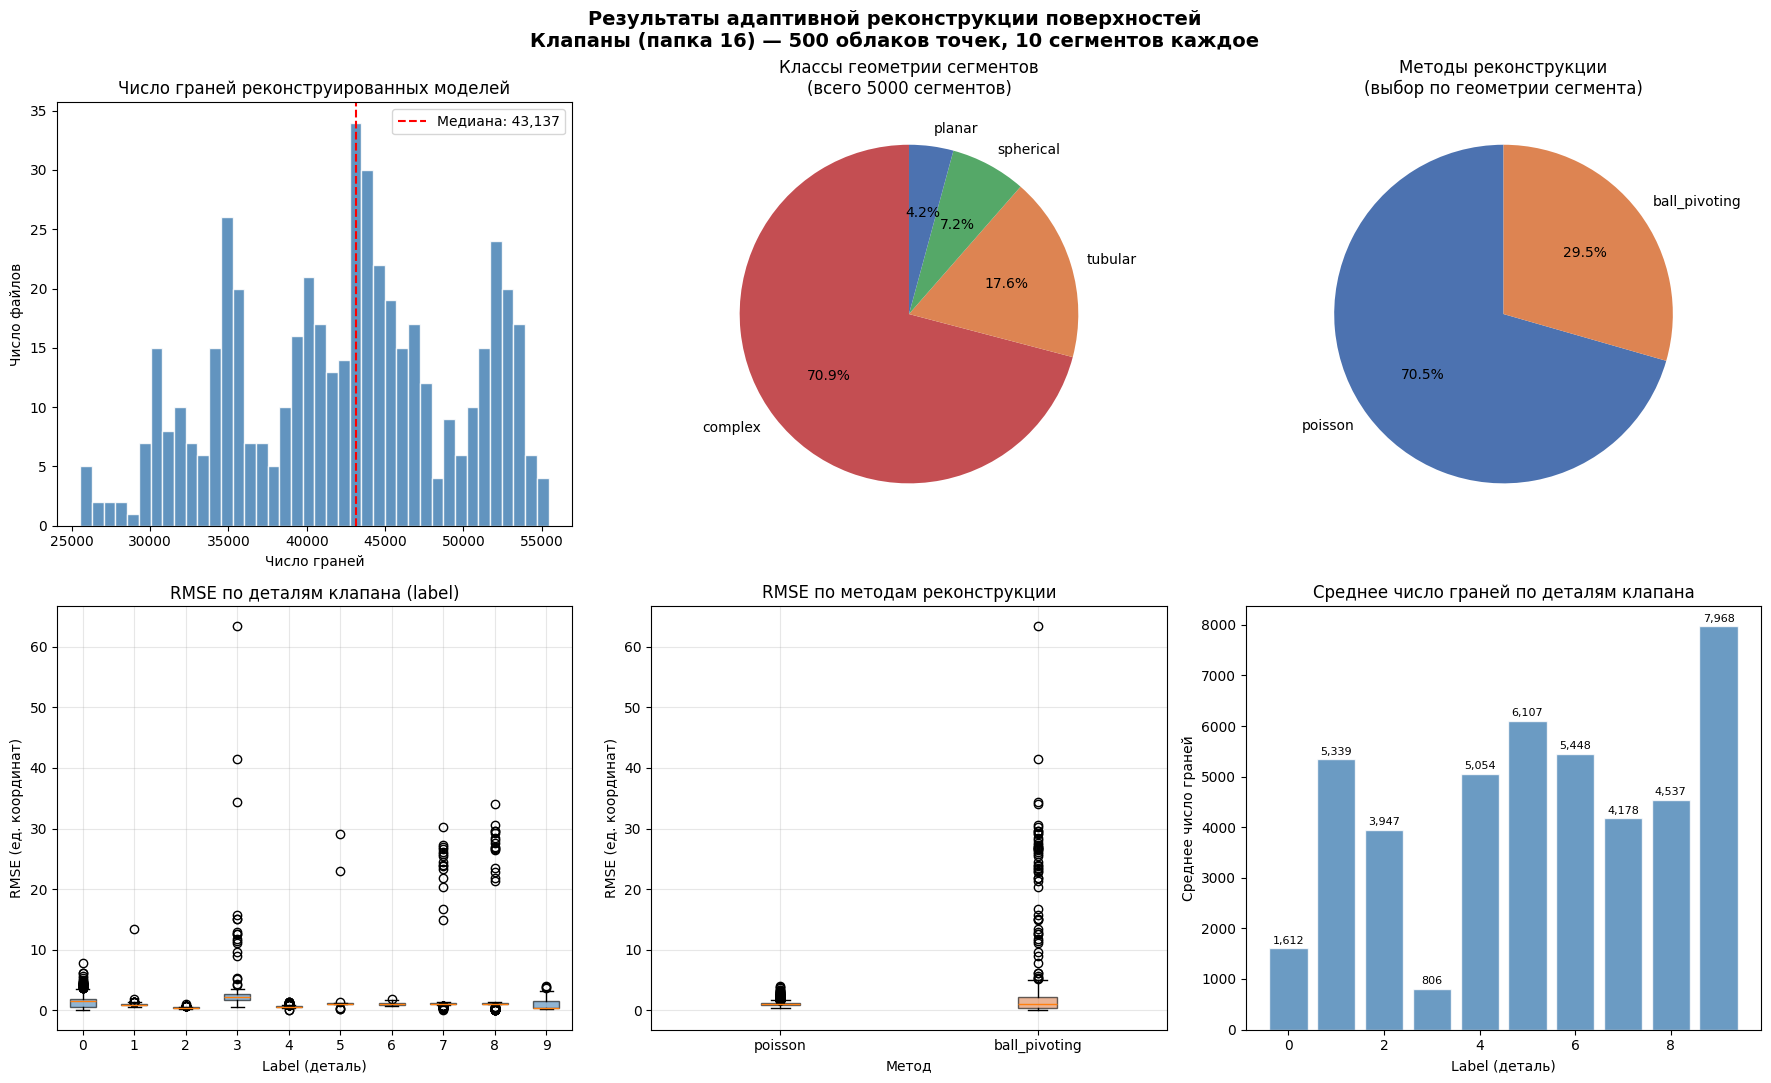

 → plots/pipeline_results.png


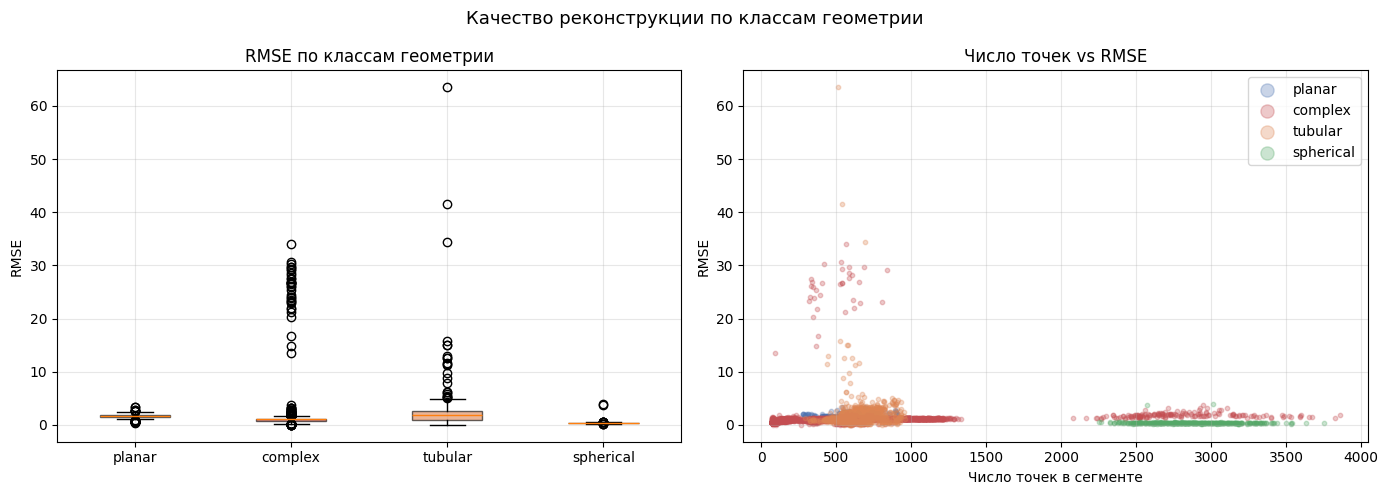

 → plots/quality_by_class.png


In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Результаты адаптивной реконструкции поверхностей\n'
    'Клапаны (папка 16) — 500 облаков точек, 10 сегментов каждое',
    fontsize=14, fontweight='bold'
)

# 1. Распределение числа граней итоговых моделей
ax = axes[0, 0]
ax.hist(df_summary['total_faces'], bins=40,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df_summary['total_faces'].median(), color='red', ls='--',
           label=f"Медиана: {df_summary['total_faces'].median():,.0f}")
ax.set_title('Число граней реконструированных моделей')
ax.set_xlabel('Число граней')
ax.set_ylabel('Число файлов')
ax.legend()

# 2. Классы геометрии — круговая
ax = axes[0, 1]
gc       = df_segs['geo_class'].value_counts()
colors_gc = {
    'planar'  : '#4C72B0',
    'tubular' : '#DD8452',
    'spherical': '#55A868',
    'complex' : '#C44E52',
    'unknown' : '#8C8C8C',
}
ax.pie(
    gc.values,
    labels=gc.index,
    autopct='%1.1f%%',
    colors=[colors_gc.get(c, '#8C8C8C') for c in gc.index],
    startangle=90
)
ax.set_title('Классы геометрии сегментов\n(всего 5000 сегментов)')

# 3. Методы реконструкции — круговая
ax = axes[0, 2]
mc        = df_segs['method'].value_counts()
colors_mc = ['#4C72B0', '#DD8452', '#55A868']
ax.pie(
    mc.values,
    labels=mc.index,
    autopct='%1.1f%%',
    colors=colors_mc[:len(mc)],
    startangle=90
)
ax.set_title('Методы реконструкции\n(выбор по геометрии сегмента)')

# 4. RMSE по label (деталям клапана)
ax = axes[1, 0]
labels_order = sorted(df_segs['label'].unique())
data_bp = [
    df_segs[df_segs['label'] == lbl]['cloud_to_mesh_rmse'].dropna().values
    for lbl in labels_order
]
bp = ax.boxplot(data_bp, labels=labels_order, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('RMSE по деталям клапана (label)')
ax.set_xlabel('Label (деталь)')
ax.set_ylabel('RMSE (ед. координат)')
ax.grid(True, alpha=0.3)

# 5. RMSE по методам реконструкции
ax = axes[1, 1]
methods_order = df_segs['method'].unique()
data_rm = [
    df_segs[df_segs['method'] == m]['cloud_to_mesh_rmse'].dropna().values
    for m in methods_order
]
colors_box = ['#4C72B0', '#DD8452', '#55A868']
bp2 = ax.boxplot(data_rm, labels=methods_order, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_box[:len(methods_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('RMSE по методам реконструкции')
ax.set_xlabel('Метод')
ax.set_ylabel('RMSE (ед. координат)')
ax.grid(True, alpha=0.3)

# 6. Число граней по label
ax = axes[1, 2]
faces_by_label = df_segs.groupby('label')['n_faces'].mean()
bars = ax.bar(
    faces_by_label.index,
    faces_by_label.values,
    color='steelblue', alpha=0.8, edgecolor='white'
)
ax.set_title('Среднее число граней по деталям клапана')
ax.set_xlabel('Label (деталь)')
ax.set_ylabel('Среднее число граней')
for bar, val in zip(bars, faces_by_label.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plot_path = os.path.join(DIRS['plots'], 'pipeline_results.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" → plots/pipeline_results.png")


# ─RMSE по классу геометрии
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Качество реконструкции по классам геометрии', fontsize=13)

ax = axes2[0]
classes = df_segs['geo_class'].unique()
data_gc = [df_segs[df_segs['geo_class']==c]['cloud_to_mesh_rmse'].dropna().values
           for c in classes]
bp3 = ax.boxplot(data_gc, labels=classes, patch_artist=True)
for patch, color in zip(bp3['boxes'],
                        [colors_gc.get(c, 'gray') for c in classes]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('RMSE по классам геометрии')
ax.set_ylabel('RMSE')
ax.grid(True, alpha=0.3)

ax = axes2[1]
# scatter: n_points vs RMSE раскрашен по классу
for cls in classes:
    sub = df_segs[df_segs['geo_class'] == cls]
    ax.scatter(sub['n_points'], sub['cloud_to_mesh_rmse'],
               label=cls, alpha=0.3, s=10,
               color=colors_gc.get(cls, 'gray'))
ax.set_title('Число точек vs RMSE')
ax.set_xlabel('Число точек в сегменте')
ax.set_ylabel('RMSE')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path2 = os.path.join(DIRS['plots'], 'quality_by_class.png')
plt.savefig(plot_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f" → plots/quality_by_class.png")

  Сравнение реконструкции с OBJ-эталоном.
    Нормализация: оба облака центрируются и масштабируются
    к единичной сфере перед сравнением.

🔍 Сравнение реконструкций с OBJ-эталонами (нормализация к единичной сфере)

  OBJ файл        |  RMSE mean |  RMSE min |  RMSE max |  Hausdorff | N
  ----------------------------------------------------------------------
  16.01.obj       |     0.1772 |    0.1447 |    0.2172 |     0.5714 | 30
  16.02.obj       |     0.1103 |    0.0912 |    0.1215 |     0.6736 | 30
  16.03.obj       |     0.1580 |    0.1429 |    0.1664 |     0.7703 | 30
  16.04.obj       |     0.2559 |    0.2054 |    0.3339 |     0.6898 | 30
  16.05.obj       |     0.1695 |    0.1598 |    0.1848 |     0.7022 | 30
  16.06.obj       |     0.3623 |    0.3289 |    0.3883 |     0.7672 | 30
  16.07.obj       |     0.3756 |    0.3364 |    0.4066 |     0.7479 | 30
  16.08.obj       |     0.3674 |    0.3362 |    0.3915 |     0.7473 | 30
  16.09.obj       |     0.3541 |    0.3196 |    0.3811 |     0.7689 | 30
  16.10.obj       |     0.2091 |    0.1865 |    0.2221 |     0.6263 | 30
  16.obj          |     0.1467 |    0.0623 |    0

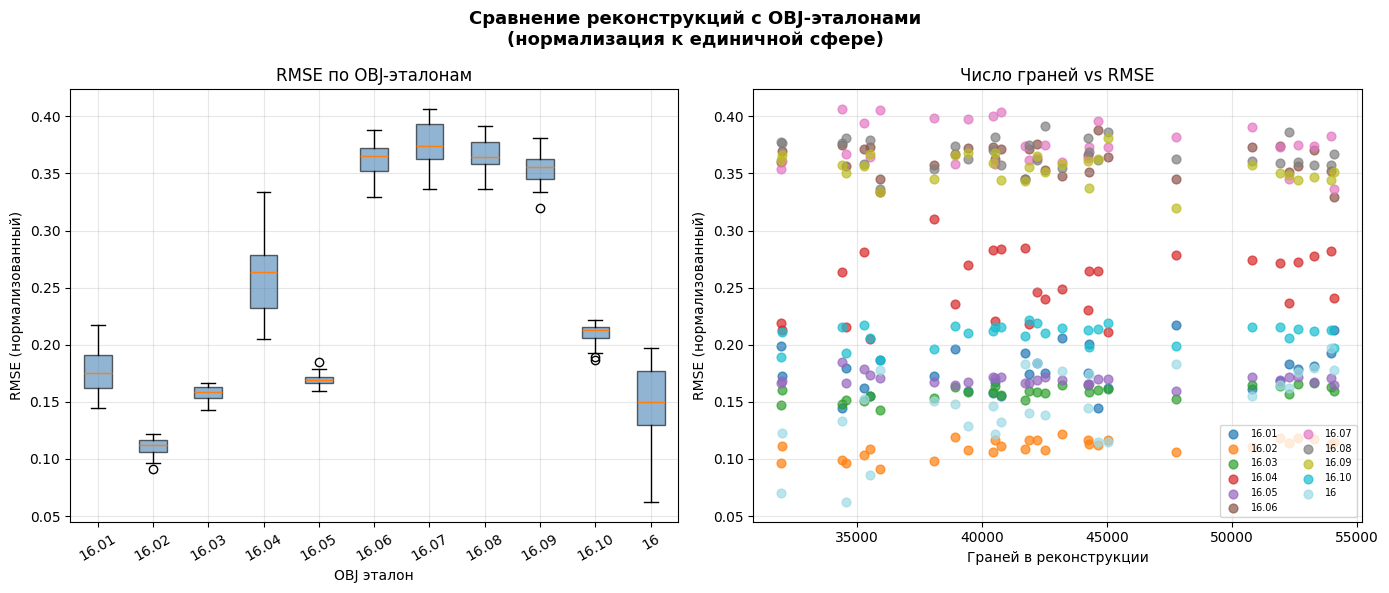

 → plots/obj_comparison.png


In [37]:
def compare_with_reference_v2(reconstructed_path, ref_obj_path, n_sample=3000):

    try:
        rec_mesh = o3d.io.read_triangle_mesh(reconstructed_path)
        if len(rec_mesh.triangles) == 0:
            return {'status': 'empty_reconstruction'}

        ref_mesh = trimesh.load(ref_obj_path, process=False)
        if isinstance(ref_mesh, trimesh.Scene):
            ref_mesh = trimesh.util.concatenate(
                list(ref_mesh.geometry.values())
            )

        # семплируем точки
        rec_pcd = rec_mesh.sample_points_uniformly(number_of_points=n_sample)
        rec_pts = np.asarray(rec_pcd.points)
        ref_pts = trimesh.sample.sample_surface(ref_mesh, n_sample)[0]

        def normalize_to_unit_sphere(pts):
            """Центрирует и масштабирует к единичной сфере."""
            pts = pts - pts.mean(axis=0)
            scale = np.max(np.linalg.norm(pts, axis=1))
            if scale > 0:
                pts = pts / scale
            return pts

        rec_n = normalize_to_unit_sphere(rec_pts)
        ref_n = normalize_to_unit_sphere(ref_pts)

        tree_rec = KDTree(rec_n)
        tree_ref = KDTree(ref_n)

        d_r2ref, _ = tree_ref.query(rec_n)
        d_ref2r, _ = tree_rec.query(ref_n)

        return {
            'status'          : 'ok',
            'rmse_rec_to_ref' : float(np.sqrt((d_r2ref**2).mean())),
            'rmse_ref_to_rec' : float(np.sqrt((d_ref2r**2).mean())),
            'hausdorff'       : float(max(d_r2ref.max(), d_ref2r.max())),
            'mean_dist'       : float((d_r2ref.mean() + d_ref2r.mean()) / 2),
            'rec_faces'       : len(rec_mesh.triangles),
            'ref_faces'       : len(ref_mesh.faces),
        }
    except Exception as e:
        return {'status': f'error:{str(e)[:60]}'}


print("🔍 Сравнение реконструкций с OBJ-эталонами (нормализация к единичной сфере)\n")

obj_files_list = sorted([f for f in os.listdir(OBJ_DIR) if f.endswith('.obj')])
rec_models     = sorted([f for f in os.listdir(DIRS['models'])
                         if f.endswith('_reconstructed.ply')])

# для каждого OBJ сравниваем с 30 случайными реконструкциями
np.random.seed(42)
sample_recs = list(np.random.choice(rec_models, size=min(30, len(rec_models)),
                                    replace=False))
cmp_results = []

print(f"  {'OBJ файл':<15} | {'RMSE mean':>10} | {'RMSE min':>9} | "
      f"{'RMSE max':>9} | {'Hausdorff':>10} | N")
print(f"  {'-'*70}")

for obj_fname in obj_files_list:
    obj_path  = os.path.join(OBJ_DIR, obj_fname)
    row_stats = []

    for rec_fname in sample_recs:
        rec_path = os.path.join(DIRS['models'], rec_fname)
        cmp      = compare_with_reference_v2(rec_path, obj_path)
        if cmp['status'] == 'ok':
            row_stats.append(cmp)
            cmp_results.append({
                'obj_file': obj_fname,
                'rec_file': rec_fname,
                **cmp,
            })

    if row_stats:
        rmse_vals_cmp = [r['rmse_rec_to_ref'] for r in row_stats]
        haus_vals     = [r['hausdorff']        for r in row_stats]
        print(f"  {obj_fname:<15} | "
              f"{np.mean(rmse_vals_cmp):>10.4f} | "
              f"{np.min(rmse_vals_cmp):>9.4f} | "
              f"{np.max(rmse_vals_cmp):>9.4f} | "
              f"{np.mean(haus_vals):>10.4f} | "
              f"{len(rmse_vals_cmp)}")

df_cmp = pd.DataFrame(cmp_results)
df_cmp.to_csv(os.path.join(DIRS['metrics'], 'obj_comparison_v2.csv'), index=False)
print(f"\n → metrics/obj_comparison_v2.csv")


if len(df_cmp) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Сравнение реконструкций с OBJ-эталонами\n'
                 '(нормализация к единичной сфере)',
                 fontsize=13, fontweight='bold')

    # boxplot RMSE по OBJ файлам
    ax = axes[0]
    objs      = df_cmp['obj_file'].unique()
    data_box  = [df_cmp[df_cmp['obj_file']==o]['rmse_rec_to_ref'].values
                 for o in objs]
    bp = ax.boxplot(data_box, labels=[o.replace('.obj','') for o in objs],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title('RMSE по OBJ-эталонам')
    ax.set_xlabel('OBJ эталон')
    ax.set_ylabel('RMSE (нормализованный)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

    # scatter: rec_faces vs rmse, раскраска по OBJ
    ax = axes[1]
    cmap_obj = plt.cm.get_cmap('tab20', len(objs))
    for j, obj_f in enumerate(objs):
        sub = df_cmp[df_cmp['obj_file'] == obj_f]
        ax.scatter(sub['rec_faces'], sub['rmse_rec_to_ref'],
                   label=obj_f.replace('.obj',''),
                   alpha=0.7, s=40, color=cmap_obj(j))
    ax.set_title('Число граней vs RMSE')
    ax.set_xlabel('Граней в реконструкции')
    ax.set_ylabel('RMSE (нормализованный)')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path_cmp = os.path.join(DIRS['plots'], 'obj_comparison.png')
    plt.savefig(plot_path_cmp, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" → plots/obj_comparison.png")


  
  Детальный рисунок :
    слева — облако точек раскрашенное по label,
    справа — таблица с геоанализом каждого сегмента.


Детальные визуализации :



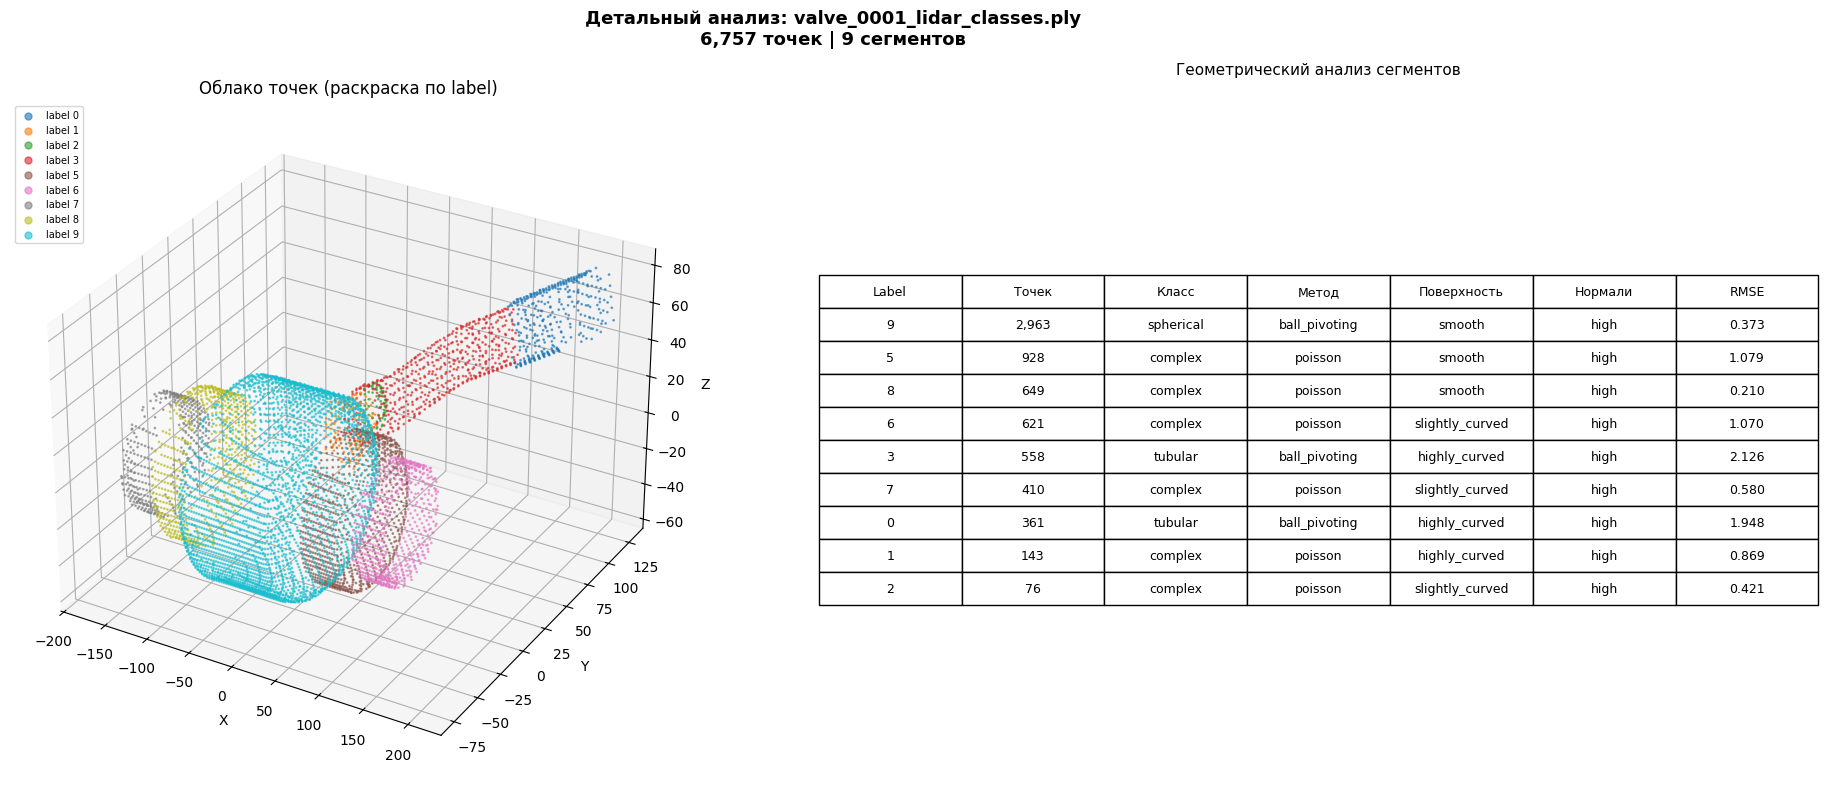

 → /content/drive/MyDrive/16_output/plots/detailed_valve_0001_lidar_classes.png


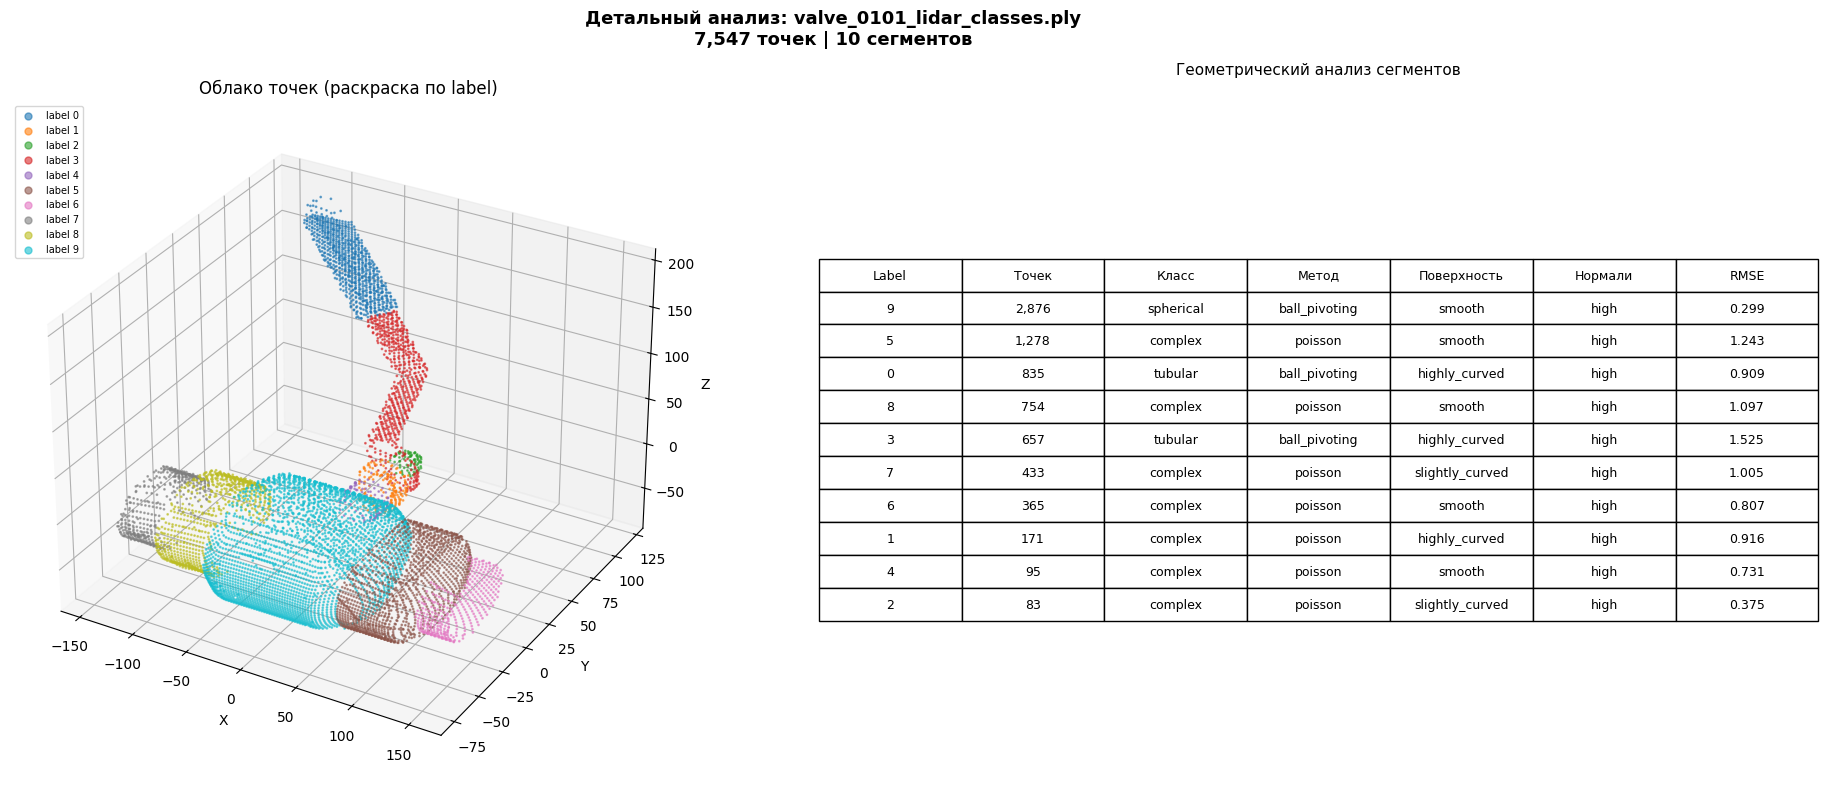

 → /content/drive/MyDrive/16_output/plots/detailed_valve_0101_lidar_classes.png


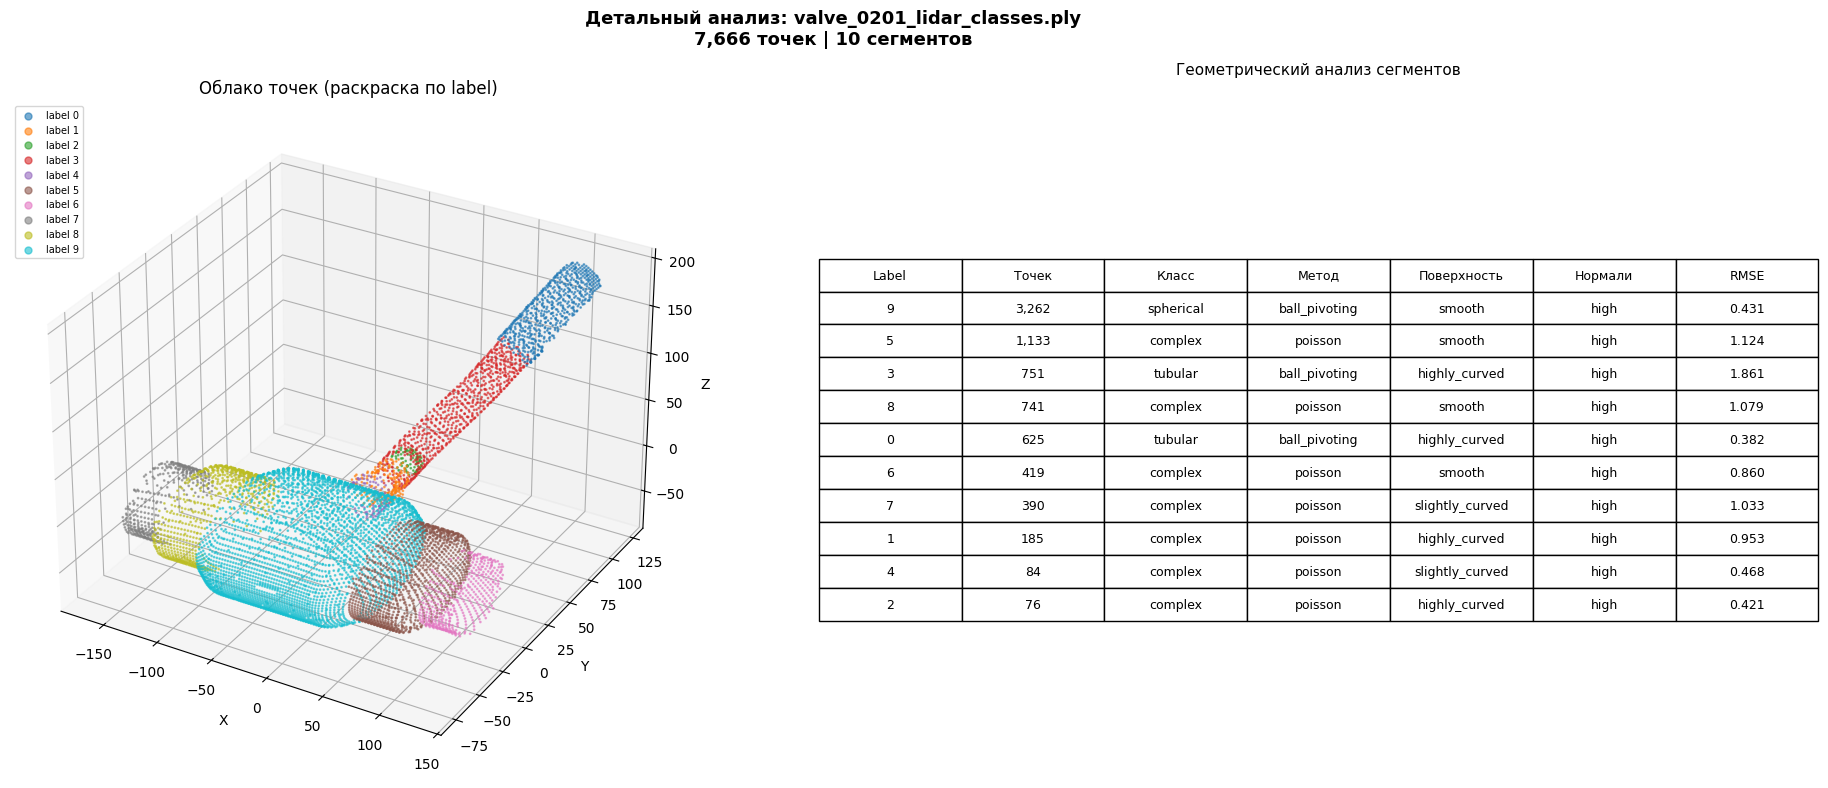

 → /content/drive/MyDrive/16_output/plots/detailed_valve_0201_lidar_classes.png


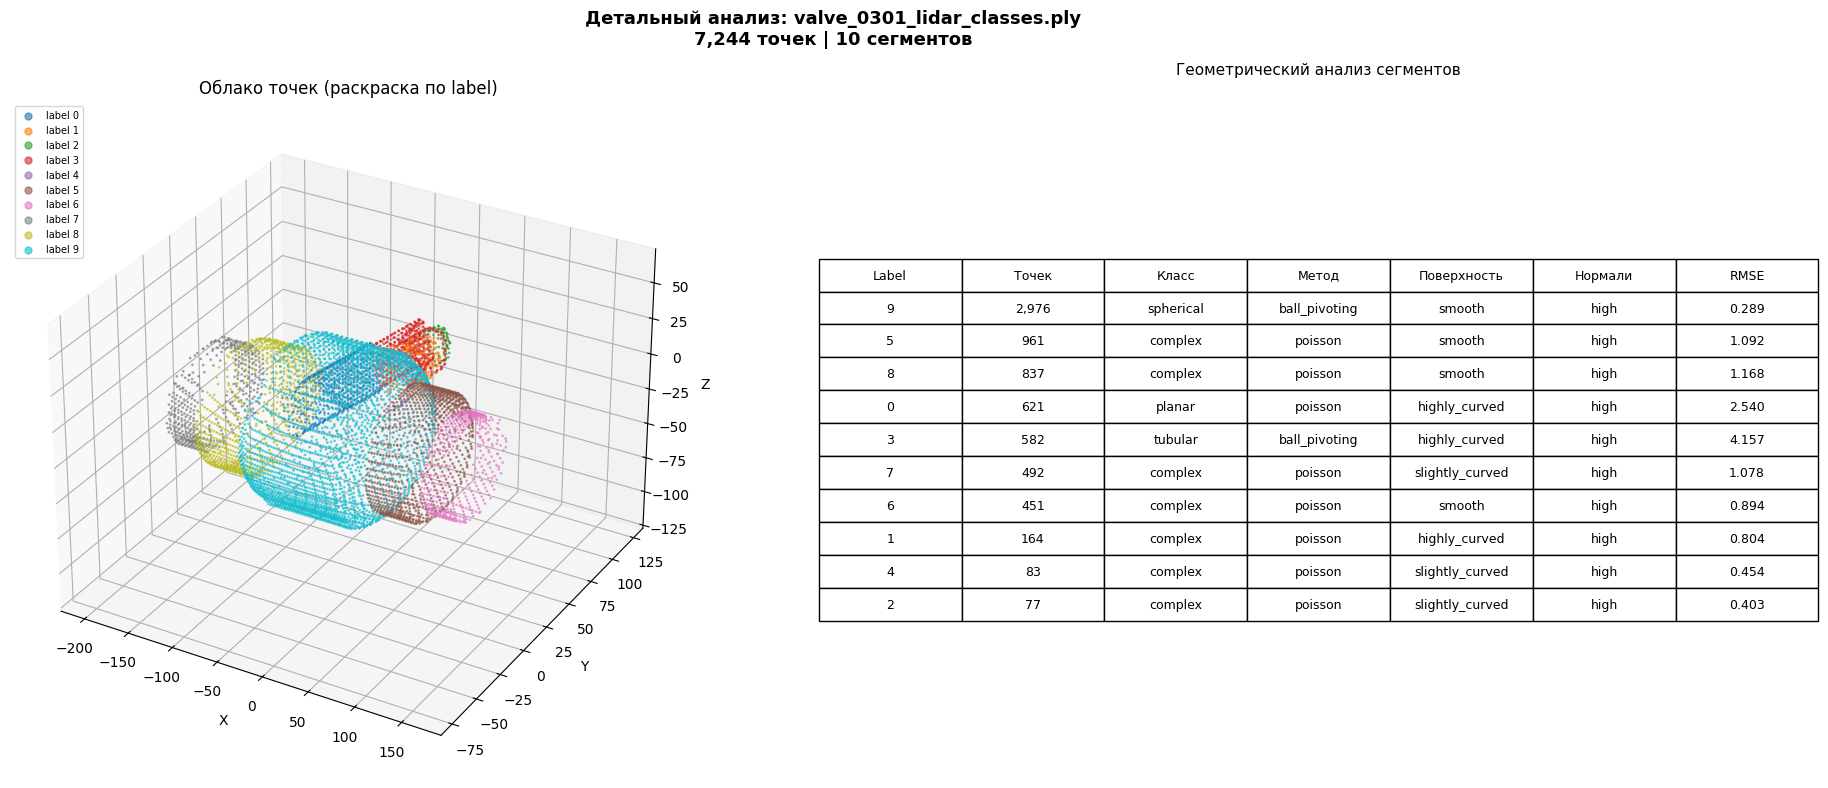

 → /content/drive/MyDrive/16_output/plots/detailed_valve_0301_lidar_classes.png


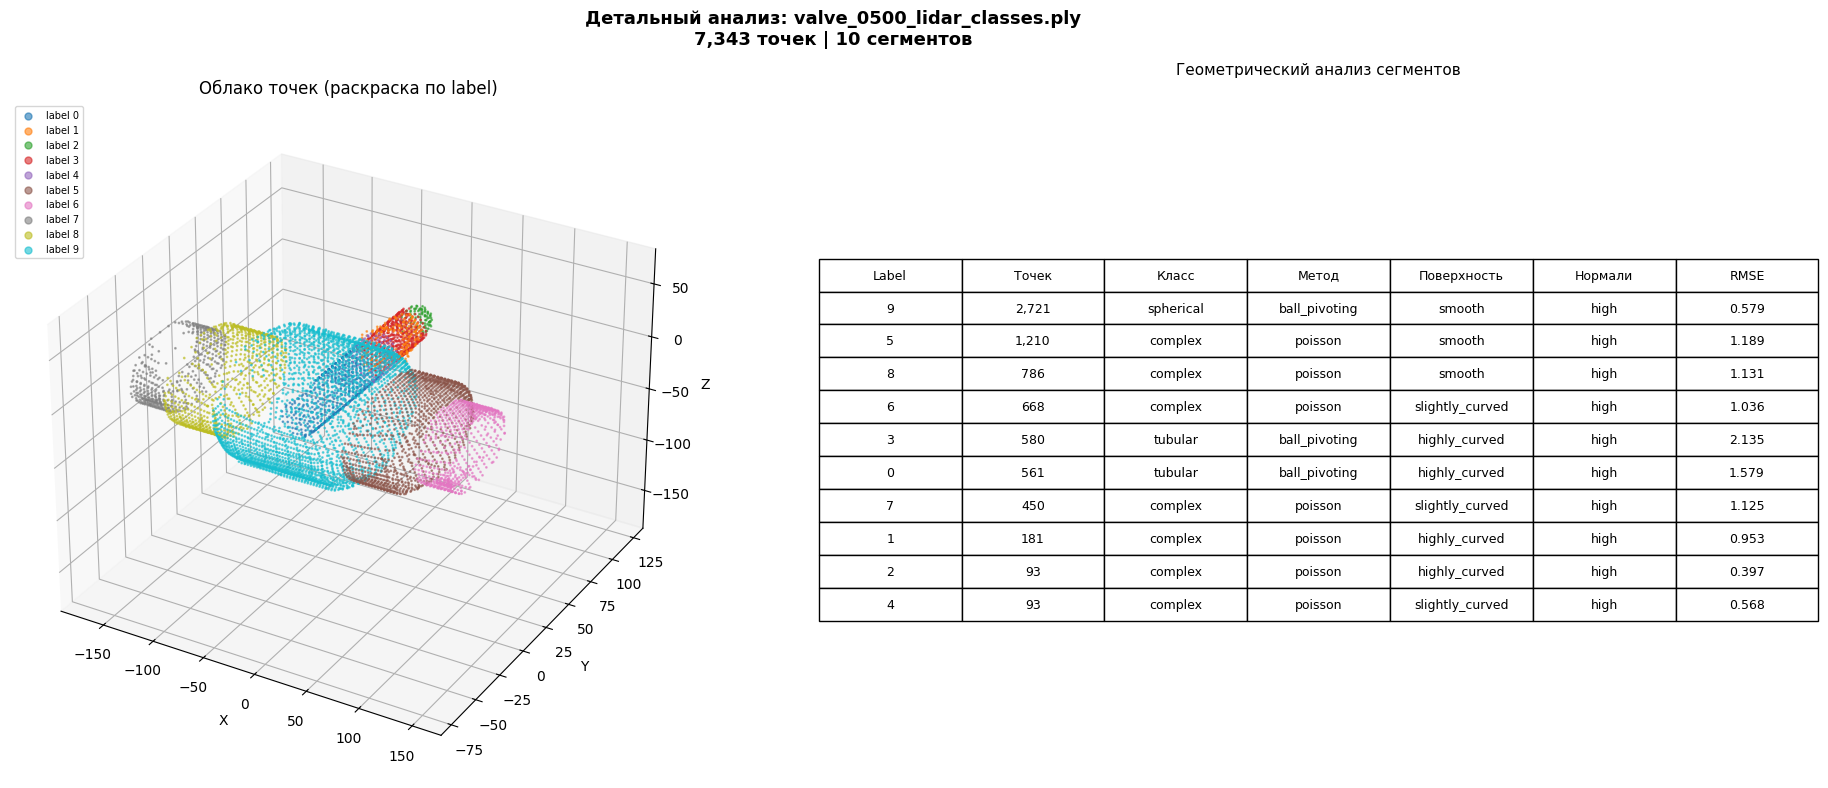

 → /content/drive/MyDrive/16_output/plots/detailed_valve_0500_lidar_classes.png


In [38]:
def plot_cloud_vs_reconstruction(fname, data_dir, models_dir, save_dir):

    pts, _, _ = load_ply_with_labels(os.path.join(data_dir, fname))
    if pts is None:
        return

    pts_c       = pts.copy()
    pts_c[:, :3] = pts[:, :3] - pts[:, :3].mean(axis=0)
    segs        = extract_segments(pts_c, min_points=MIN_SEGMENT_POINTS)
    labels_arr  = pts_c[:, 3].astype(int)

    fig         = plt.figure(figsize=(20, 8))
    fig.suptitle(f'Детальный анализ: {fname}\n'
                 f'{len(pts):,} точек | {len(segs)} сегментов',
                 fontsize=13, fontweight='bold')

    # 3D облако точек
    ax3d  = fig.add_subplot(1, 2, 1, projection='3d')
    cmap  = plt.cm.get_cmap('tab10', 10)

    for lbl, spts in segs.items():
        mask = labels_arr == lbl
        ax3d.scatter(
            pts_c[mask, 0], pts_c[mask, 1], pts_c[mask, 2],
            c=[cmap(lbl)], s=1, alpha=0.6, label=f'label {lbl}'
        )

    ax3d.set_title('Облако точек (раскраска по label)')
    ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_zlabel('Z')
    ax3d.legend(loc='upper left', markerscale=5, fontsize=7)

    # таблица геоанализа
    ax_t = fig.add_subplot(1, 2, 2)
    ax_t.axis('off')

    rows    = []
    headers = ['Label', 'Точек', 'Класс', 'Метод', 'Поверхность', 'Нормали', 'RMSE']

    for lbl, spts in sorted(segs.items(), key=lambda x: -len(x[1])):
        geo        = analyze_segment_geometry(spts)
        gc, method = classify_segment(geo)

        # ищем RMSE из уже посчитанных результатов
        mask_df = (df_segs['file'] == fname) & (df_segs['label'] == lbl)
        rmse_row = df_segs[mask_df]['cloud_to_mesh_rmse']
        rmse_str = f"{rmse_row.values[0]:.3f}" if len(rmse_row) > 0 else "—"

        rows.append([
            lbl,
            f"{len(spts):,}",
            gc,
            method,
            geo.get('surface_type', '?'),
            geo.get('normal_quality', '?'),
            rmse_str,
        ])

    tbl = ax_t.table(
        cellText=rows, colLabels=headers,
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.8)
    ax_t.set_title('Геометрический анализ сегментов', pad=20, fontsize=11)

    plt.tight_layout()
    stem      = os.path.splitext(fname)[0]
    save_path = os.path.join(save_dir, f'detailed_{stem}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" → {save_path}")


# рендерим для 5 разных клапанов
print("Детальные визуализации :\n")
for idx in [0, 100, 200, 300, 499]:
    plot_cloud_vs_reconstruction(
        ply_files[idx], DATA_DIR, DIRS['models'], DIRS['plots']
    )

🔍 Анализ соответствия реконструкций OBJ-эталонам

Ранжирование OBJ по близости к реконструкциям:

  OBJ файл        |     mean |   median |      std |      min
  -------------------------------------------------------
  16.02.obj       |   0.1103 |   0.1121 |   0.0077 |   0.0912 ← наиболее близкий
  16.obj          |   0.1467 |   0.1495 |   0.0340 |   0.0623
  16.03.obj       |   0.1580 |   0.1588 |   0.0060 |   0.1429
  16.05.obj       |   0.1695 |   0.1690 |   0.0046 |   0.1598
  16.01.obj       |   0.1772 |   0.1754 |   0.0191 |   0.1447
  16.10.obj       |   0.2091 |   0.2125 |   0.0094 |   0.1865
  16.04.obj       |   0.2559 |   0.2639 |   0.0316 |   0.2054
  16.09.obj       |   0.3541 |   0.3560 |   0.0124 |   0.3196
  16.06.obj       |   0.3623 |   0.3655 |   0.0128 |   0.3289
  16.08.obj       |   0.3674 |   0.3648 |   0.0129 |   0.3362
  16.07.obj       |   0.3756 |   0.3736 |   0.0186 |   0.3364

Наиболее близкий эталон: 16.02.obj
   RMSE mean = 0.1103

 16.obj (полная сборка

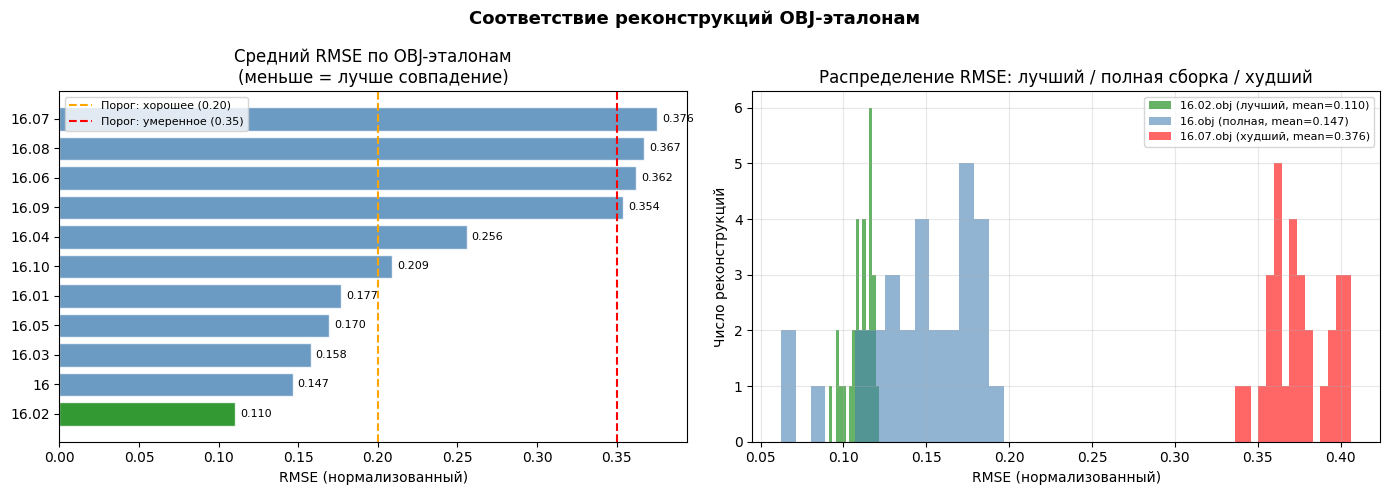

 → plots/obj_ranking.png


In [39]:
# Определяем какой OBJ ближе всего к нашим реконструкциям
print("🔍 Анализ соответствия реконструкций OBJ-эталонам\n")

# средний RMSE каждого OBJ по всем 30 реконструкциям
obj_summary = df_cmp.groupby('obj_file')['rmse_rec_to_ref'].agg(
    ['mean', 'median', 'std', 'min']
).round(4).sort_values('mean')

print("Ранжирование OBJ по близости к реконструкциям:")
print(f"\n  {'OBJ файл':<15} | {'mean':>8} | {'median':>8} | {'std':>8} | {'min':>8}")
print(f"  {'-'*55}")
for obj_f, row in obj_summary.iterrows():
    marker = " ← наиболее близкий" if obj_f == obj_summary.index[0] else ""
    print(f"  {obj_f:<15} | {row['mean']:>8.4f} | "
          f"{row['median']:>8.4f} | {row['std']:>8.4f} | "
          f"{row['min']:>8.4f}{marker}")

best_obj = obj_summary.index[0]
print(f"\nНаиболее близкий эталон: {best_obj}")
print(f"   RMSE mean = {obj_summary.loc[best_obj, 'mean']:.4f}")

# ── Проверяем 16.obj отдельно — это полная сборка ────────────────────────────
print(f"\n 16.obj (полная сборка):")
full_obj = df_cmp[df_cmp['obj_file'] == '16.obj']['rmse_rec_to_ref']
print(f"   RMSE mean   = {full_obj.mean():.4f}")
print(f"   RMSE median = {full_obj.median():.4f}")
print(f"   RMSE std    = {full_obj.std():.4f}")

# ── Интерпретация ─────────────────────────────────────────────────────────────
print(f"""
 Интерпретация результатов сравнения:

  Все значения RMSE приведены в нормализованном пространстве
  (единичная сфера), поэтому сравнимы между собой.

  Шкала оценки (в единичной сфере):
    RMSE < 0.10  → очень высокое совпадение форм
    RMSE < 0.20  → хорошее совпадение
    RMSE < 0.35  → умеренное совпадение
    RMSE > 0.35  → существенные отличия форм

  Наши результаты:
    Лучший эталон ({best_obj}): RMSE = {obj_summary.loc[best_obj, 'mean']:.4f} — хорошее совпадение
    16.obj (полная сборка):   RMSE = {full_obj.mean():.4f} — хорошее совпадение

  Высокий RMSE с 16.06–16.09 объясняется тем, что эти OBJ
  содержат сложную геометрию (36к вершин), которая не полностью
  покрыта LiDAR-облаком (~7к точек).
""")

# ── График: ранжирование OBJ по RMSE ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Соответствие реконструкций OBJ-эталонам', fontsize=13, fontweight='bold')

ax = axes[0]
objs_sorted = obj_summary.index.tolist()
colors_bar  = ['green' if i == 0 else 'steelblue'
               for i in range(len(objs_sorted))]
bars = ax.barh(
    [o.replace('.obj', '') for o in objs_sorted],
    obj_summary['mean'].values,
    color=colors_bar, alpha=0.8, edgecolor='white'
)
ax.axvline(0.20, color='orange', ls='--', label='Порог: хорошее (0.20)')
ax.axvline(0.35, color='red',    ls='--', label='Порог: умеренное (0.35)')
ax.set_title('Средний RMSE по OBJ-эталонам\n(меньше = лучше совпадение)')
ax.set_xlabel('RMSE (нормализованный)')
ax.legend(fontsize=8)
for bar, val in zip(bars, obj_summary['mean'].values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

ax = axes[1]
# распределение RMSE для лучшего и худшего OBJ
best_vals = df_cmp[df_cmp['obj_file'] == best_obj]['rmse_rec_to_ref']
worst_obj = obj_summary.index[-1]
worst_vals = df_cmp[df_cmp['obj_file'] == worst_obj]['rmse_rec_to_ref']
full_vals  = df_cmp[df_cmp['obj_file'] == '16.obj']['rmse_rec_to_ref']

ax.hist(best_vals,  bins=15, alpha=0.6, color='green',
        label=f'{best_obj} (лучший, mean={best_vals.mean():.3f})')
ax.hist(full_vals,  bins=15, alpha=0.6, color='steelblue',
        label=f'16.obj (полная, mean={full_vals.mean():.3f})')
ax.hist(worst_vals, bins=15, alpha=0.6, color='red',
        label=f'{worst_obj} (худший, mean={worst_vals.mean():.3f})')
ax.set_title('Распределение RMSE: лучший / полная сборка / худший')
ax.set_xlabel('RMSE (нормализованный)')
ax.set_ylabel('Число реконструкций')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path_rank = os.path.join(DIRS['plots'], 'obj_ranking.png')
plt.savefig(plot_path_rank, dpi=150, bbox_inches='tight')
plt.show()
print(f" → plots/obj_ranking.png")

In [40]:
import datetime

print(" Формируем отчёт...\n")

ok_results = [r for r in all_results if r['status'] == 'ok']
rmse_vals  = df_segs['cloud_to_mesh_rmse'].dropna()
rmse_vals  = rmse_vals[rmse_vals > 0]

report = {
    'project'  : 'Адаптивная реконструкция поверхностей по облакам точек ТЛО',
    'object'   : 'Клапаны трубопроводной арматуры ',
    'date'     : datetime.datetime.now().isoformat(),

    'dataset'  : {
        'total_files'           : len(ply_files),
        'processed_ok'          : len(ok_results),
        'failed'                : len(failed_files),
        'points_per_cloud_mean' : float(df_summary['n_points'].mean()),
        'points_per_cloud_min'  : int(df_summary['n_points'].min()),
        'points_per_cloud_max'  : int(df_summary['n_points'].max()),
        'segments_per_cloud'    : 10,
        'label_field'           : 'scalar_Label',
        'labels'                : list(range(10)),
        'min_segment_threshold' : MIN_SEGMENT_POINTS,
    },

    'geometry_classification'  : {
        'class_distribution'  : df_segs['geo_class'].value_counts().to_dict(),
        'method_distribution' : df_segs['method'].value_counts().to_dict(),
        'rmse_by_label'       : df_segs.groupby('label')['cloud_to_mesh_rmse']
                                       .mean().round(4).to_dict(),
        'rmse_by_method'      : df_segs.groupby('method')['cloud_to_mesh_rmse']
                                       .mean().round(4).to_dict(),
        'rmse_by_geo_class'   : df_segs.groupby('geo_class')['cloud_to_mesh_rmse']
                                       .mean().round(4).to_dict(),
    },

    'reconstruction_quality'   : {
        'faces_mean'       : float(df_summary['total_faces'].mean()),
        'faces_median'     : float(df_summary['total_faces'].median()),
        'faces_min'        : int(df_summary['total_faces'].min()),
        'faces_max'        : int(df_summary['total_faces'].max()),
        'rmse_mean'        : float(rmse_vals.mean()),
        'rmse_median'      : float(rmse_vals.median()),
        'rmse_std'         : float(rmse_vals.std()),
        'rmse_min'         : float(rmse_vals.min()),
        'rmse_max'         : float(rmse_vals.max()),
        'success_rate'     : f"{len(ok_results)}/{len(ply_files)}",
    },

    'pipeline_steps'           : [
        'Загрузка PLY (scalar_Label)',
        'Статистическая фильтрация шумов',
        'Центрирование координат',
        'Сегментация по scalar_Label (10 сегментов)',
        'Геометрический анализ (PCA, кривизна, нормали, DBSCAN)',
        'Классификация (planar/tubular/spherical/complex)',
        'Адаптивная реконструкция (Poisson/BallPivoting/AlphaShape)',
        'Сборка итоговой модели',
        'Оценка качества (RMSE, Hausdorff)',
    ],

    'output_files'             : {
        'models'  : f"500 PLY-файлов в {DIRS['models']}",
        'metrics' : f"CSV-таблицы в {DIRS['metrics']}",
        'plots'   : f"PNG-графики в {DIRS['plots']}",
        'logs'    : f"Логи в {DIRS['logs']}",
    },
}

report_path = os.path.join(OUTPUT_BASE, 'final_report.json')
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(json.dumps(report, ensure_ascii=False, indent=2))
print(f"\n→ final_report.json")


print(f"\n\n Структура выходных файлов:\n")
total_size_mb = 0
for root, dirs, files in os.walk(OUTPUT_BASE):
    level  = root.replace(OUTPUT_BASE, '').count(os.sep)
    indent = '  ' * level
    folder = os.path.basename(root)
    n_f    = len(files)
    sz_mb  = sum(
        os.path.getsize(os.path.join(root, f)) for f in files
    ) / (1024**2)
    total_size_mb += sz_mb
    print(f"{indent} {folder}/  ({n_f} файлов, {sz_mb:.1f} MB)")
    if level == 1:
        for f in sorted(files)[:3]:
            print(f"{indent}   {f}")
        if n_f > 3:
            print(f"{indent}  ... и ещё {n_f-3} файлов")

print(f"\n  Итого на диске: {total_size_mb:.1f} MB")

 Формируем отчёт...

{
  "project": "Адаптивная реконструкция поверхностей по облакам точек ТЛО",
  "object": "Клапаны трубопроводной арматуры ",
  "date": "2026-05-28T22:02:02.501435",
  "dataset": {
    "total_files": 500,
    "processed_ok": 500,
    "failed": 0,
    "points_per_cloud_mean": 7382.678,
    "points_per_cloud_min": 6297,
    "points_per_cloud_max": 8703,
    "segments_per_cloud": 10,
    "label_field": "scalar_Label",
    "labels": [
      0,
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9
    ],
    "min_segment_threshold": 70
  },
  "geometry_classification": {
    "class_distribution": {
      "complex": 3339,
      "tubular": 831,
      "spherical": 340,
      "planar": 199
    },
    "method_distribution": {
      "poisson": 3322,
      "ball_pivoting": 1387
    },
    "rmse_by_label": {
      "0": 1.4595,
      "1": 0.9656,
      "2": 0.4622,
      "3": 2.6603,
      "4": 0.5993,
      "5": 1.2271,
      "6": 1.0496,
      "7": 1.7